# SmolVLM training run analysis

Reads `metrics.json` from each version's `outputs/` folder and produces visualizations.

**Expected layout** (relative to wherever you keep this notebook — adjust `ROOT` in the next cell):

```
<ROOT>/
  v1/outputs/metrics.json
  v2/outputs/metrics.json
  v3/outputs/metrics.json
  ...
```

Set `ROOT` and `VERSIONS` below, then run all cells. Per-version plots and a cross-version comparison get saved under `OUT_DIR`.

## 1. Configure

In [10]:
from pathlib import Path

ROOT     = Path("./notebooks")
VERSIONS = ["v1", "v2", "v3", "v4", "v5", "v6", "v7", "v8", "v9", "v10", "v11", "v12", "v13"]
OUT_DIR  = Path("./analysis_plots")

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Reading from: {ROOT.resolve()}")
print(f"Writing to:   {OUT_DIR.resolve()}")
print(f"Versions:     {VERSIONS}")

Reading from: C:\Users\Kai\Desktop\Files\New York University\Spring 2026\CSGY-6953 Deep Learning\Final\notebooks
Writing to:   C:\Users\Kai\Desktop\Files\New York University\Spring 2026\CSGY-6953 Deep Learning\Final\analysis_plots
Versions:     ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13']


## 2. Imports

In [11]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Helpers

In [12]:
def load_metrics(root: Path, version: str):
    path = root / version / "metrics.json"
    if not path.exists():
        print(f"[!] no metrics.json at {path} — skipping {version}")
        return None
    with open(path) as f:
        data = json.load(f)
    data["_version"] = version
    return data


def smooth(ys, window=25):
    if len(ys) < window:
        return list(ys)
    ys = list(ys)
    out = []
    for i in range(len(ys)):
        lo = max(0, i - window + 1)
        out.append(sum(ys[lo:i + 1]) / (i - lo + 1))
    return out

## 4. Per-version plot functions

In [13]:
def plot_training_dynamics(m, out_path):
    """Loss / LR / grad-norm / val-accuracy panels for a single run."""
    steps = m.get("step_metrics", [])
    evals = m.get("eval_metrics", [])
    zs    = m.get("meta", {}).get("zero_shot_val_acc")

    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f"Training dynamics — {m['_version']}", fontsize=13, fontweight="bold")

    if steps:
        xs   = [s["step"]      for s in steps]
        loss = [s["loss"]      for s in steps]
        lr   = [s["lr"]        for s in steps]
        gn   = [s["grad_norm"] for s in steps]

        ax[0, 0].plot(xs, loss, alpha=0.25, label="raw")
        ax[0, 0].plot(xs, smooth(loss, 25), label="smoothed (window=25)")
        ax[0, 0].set_xlabel("optimizer step"); ax[0, 0].set_ylabel("loss")
        ax[0, 0].set_title("Training loss (CE on answer letter)")
        ax[0, 0].legend(); ax[0, 0].grid(alpha=0.3)

        ax[0, 1].plot(xs, lr)
        ax[0, 1].set_xlabel("optimizer step"); ax[0, 1].set_ylabel("lr")
        ax[0, 1].set_title("Learning rate schedule (cosine w/ warmup)")
        ax[0, 1].grid(alpha=0.3)

        ax[1, 0].plot(xs, gn, alpha=0.4, label="raw")
        ax[1, 0].plot(xs, smooth(gn, 25), label="smoothed")
        ax[1, 0].set_xlabel("optimizer step"); ax[1, 0].set_ylabel("‖grad‖ (pre-clip)")
        ax[1, 0].set_title("Gradient norm")
        ax[1, 0].axhline(1.0, color="red", ls=":", alpha=0.5, label="clip = 1.0")
        ax[1, 0].legend(); ax[1, 0].grid(alpha=0.3)

    if evals:
        ex = [e["step"]    for e in evals]
        ey = [e["val_acc"] for e in evals]
        ax[1, 1].plot(ex, ey, "o-", label="LoRA val acc")
        if zs is not None:
            ax[1, 1].axhline(zs, color="gray", ls="--", label=f"zero-shot ({zs:.3f})")
        ax[1, 1].axhline(0.36, color="red", ls=":", alpha=0.6, label="all-zero floor (0.36)")
        ax[1, 1].set_xlabel("optimizer step"); ax[1, 1].set_ylabel("val accuracy")
        ax[1, 1].set_title("Validation accuracy during training")
        ax[1, 1].legend(); ax[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def _bar(ax, data, title, xlabel, sort_numeric=False):
    if not data:
        ax.text(0.5, 0.5, "no data", ha="center", va="center")
        ax.set_title(title)
        return
    keys = sorted(data.keys(), key=int) if sort_numeric else list(data.keys())
    accs = [data[k]["acc"] for k in keys]
    ns   = [data[k]["n"]   for k in keys]
    bars = ax.bar(keys, accs)
    for b, n, a in zip(bars, ns, accs):
        ax.text(b.get_x() + b.get_width() / 2, a + 0.01, f"{a:.2f}\nn={n}",
                ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, max(accs) * 1.25 if accs else 1)
    ax.set_ylabel("accuracy"); ax.set_xlabel(xlabel); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)


def plot_val_breakdown(m, out_path):
    """Where the model wins/loses on val: by num_choices, answer index, subject, and pred-vs-gold."""
    bd = (m.get("final") or {}).get("val_breakdown")
    if bd is None:
        evals = m.get("eval_metrics", [])
        bd = evals[-1].get("breakdown") if evals and "breakdown" in evals[-1] else None
    if bd is None:
        print(f"[!] {m['_version']}: no val breakdown available, skipping val_breakdown plot")
        return

    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f"Validation breakdown — {m['_version']} (overall {bd['overall_acc']:.3f})",
                 fontsize=13, fontweight="bold")

    _bar(ax[0, 0], bd.get("by_num_choices", {}), "Accuracy by num_choices", "num_choices", sort_numeric=True)
    _bar(ax[0, 1], bd.get("by_answer_idx", {}),  "Accuracy by gold answer", "answer index", sort_numeric=True)
    _bar(ax[1, 0], bd.get("by_subject", {}),     "Accuracy by subject",     "subject")

    preds = bd.get("pred_distribution", {})
    gold  = bd.get("gold_distribution", {})
    idxs  = sorted(set(preds) | set(gold), key=int)
    x = np.arange(len(idxs)); w = 0.38
    ax[1, 1].bar(x - w / 2, [gold.get(i, 0)  for i in idxs], width=w, label="gold")
    ax[1, 1].bar(x + w / 2, [preds.get(i, 0) for i in idxs], width=w, label="predicted")
    ax[1, 1].set_xticks(x); ax[1, 1].set_xticklabels(idxs)
    ax[1, 1].set_xlabel("answer index"); ax[1, 1].set_ylabel("count")
    ax[1, 1].set_title("Prediction vs. gold distribution (val)")
    ax[1, 1].legend(); ax[1, 1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def plot_confusion(m, out_path):
    """Confusion matrix on val for the best/final adapter."""
    bd = (m.get("final") or {}).get("val_breakdown")
    if bd is None:
        evals = m.get("eval_metrics", [])
        bd = evals[-1].get("breakdown") if evals and "breakdown" in evals[-1] else None
    if bd is None or "confusion" not in bd:
        print(f"[!] {m['_version']}: no confusion data, skipping confusion_matrix plot")
        return

    conf = bd["confusion"]
    labels = sorted({k for k in conf} | {p for row in conf.values() for p in row}, key=int)
    mat = np.zeros((len(labels), len(labels)), dtype=int)
    idx = {l: i for i, l in enumerate(labels)}
    for gold, row in conf.items():
        for pred, cnt in row.items():
            mat[idx[gold], idx[pred]] = cnt

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("gold")
    ax.set_title(f"Confusion matrix — {m['_version']}")
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = "white" if mat[i, j] > mat.max() / 2 else "black"
            ax.text(j, i, str(mat[i, j]), ha="center", va="center", color=color, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

## 5. Cross-version plots and summary table

In [14]:
def plot_val_curves(all_metrics, out_path):
    """All versions' val accuracy on one set of axes."""
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = plt.get_cmap("tab20").colors  # 20 distinct colors; no collision for ≤20 versions
    for i, m in enumerate(all_metrics):
        evals = m.get("eval_metrics", [])
        if not evals:
            continue
        xs = [e["step"]    for e in evals]
        ys = [e["val_acc"] for e in evals]
        ax.plot(xs, ys, "o-", color=colors[i],
                label=f"{m['_version']} (best {max(ys):.3f})")
    ax.axhline(0.36, color="red", ls=":", alpha=0.6, label="all-zero floor (0.36)")
    ax.set_xlabel("optimizer step"); ax.set_ylabel("val accuracy")
    ax.set_title("Validation accuracy across versions"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def plot_best_val_bars(all_metrics, out_path):
    """Side-by-side zero-shot vs best-LoRA bars per version."""
    rows = []
    for m in all_metrics:
        evals = m.get("eval_metrics", [])
        best  = max((e["val_acc"] for e in evals), default=None)
        zs    = m.get("meta", {}).get("zero_shot_val_acc")
        rows.append((m["_version"], zs, best))

    fig, ax = plt.subplots(figsize=(max(7, 1.5 * len(rows)), 5))
    x = np.arange(len(rows)); w = 0.38
    zs_vals   = [r[1] if r[1] is not None else 0 for r in rows]
    best_vals = [r[2] if r[2] is not None else 0 for r in rows]
    ax.bar(x - w / 2, zs_vals,   width=w, label="zero-shot")
    ax.bar(x + w / 2, best_vals, width=w, label="best LoRA")
    for i, (zs, bv) in enumerate(zip(zs_vals, best_vals)):
        if zs: ax.text(i - w / 2, zs + 0.005, f"{zs:.3f}", ha="center", fontsize=8)
        if bv: ax.text(i + w / 2, bv + 0.005, f"{bv:.3f}", ha="center", fontsize=8)
    ax.axhline(0.36, color="red", ls=":", alpha=0.6, label="all-zero floor (0.36)")
    ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
    ax.set_ylabel("val accuracy"); ax.set_title("Best val accuracy per version")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()


def build_summary_table(all_metrics, out_path):
    rows = []
    for m in all_metrics:
        meta  = m.get("meta", {})
        final = m.get("final", {}) or {}
        evals = m.get("eval_metrics", [])
        best  = max((e["val_acc"] for e in evals), default=None)
        cfg   = meta.get("config", {}) or {}
        rows.append({
            "version":          m["_version"],
            "zero_shot_acc":    meta.get("zero_shot_val_acc"),
            "best_val_acc":     best,
            "final_val_acc":    final.get("final_val_acc"),
            "trainable_params": meta.get("trainable_params"),
            "total_train_hr":   round(meta.get("total_train_seconds", 0) / 3600, 3),
            "peak_gpu_mem_mb":  meta.get("peak_gpu_mem_mb"),
            "epochs":           cfg.get("epochs"),
            "lr":               cfg.get("lr"),
            "batch_size":       cfg.get("batch_size"),
            "grad_accum":       cfg.get("grad_accum"),
            "lora_r":           cfg.get("lora_r"),
            "lora_alpha":       cfg.get("lora_alpha"),
            "use_cot":          cfg.get("use_cot"),
            "image_edge":       cfg.get("image_longest_edge"),
            "finished":         meta.get("finished"),
        })
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    return df

## 6. Load metrics for all configured versions

In [15]:
loaded = []
for v in VERSIONS:
    m = load_metrics(ROOT, v)
    if m is not None:
        loaded.append(m)
print(f"\nLoaded {len(loaded)} of {len(VERSIONS)} versions: {[m['_version'] for m in loaded]}")


Loaded 13 of 13 versions: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13']


## 7. Per-version plots

One section per version: training dynamics → val breakdown → confusion matrix.


v1


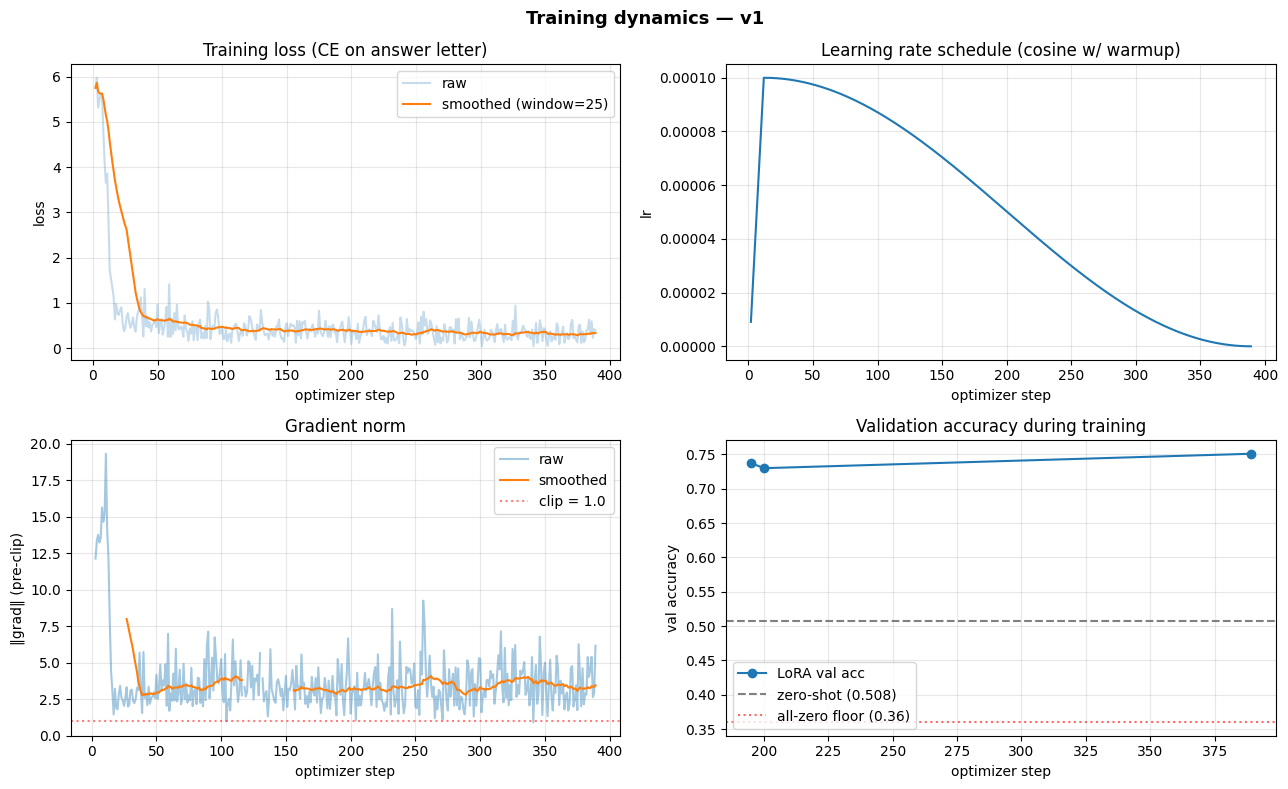

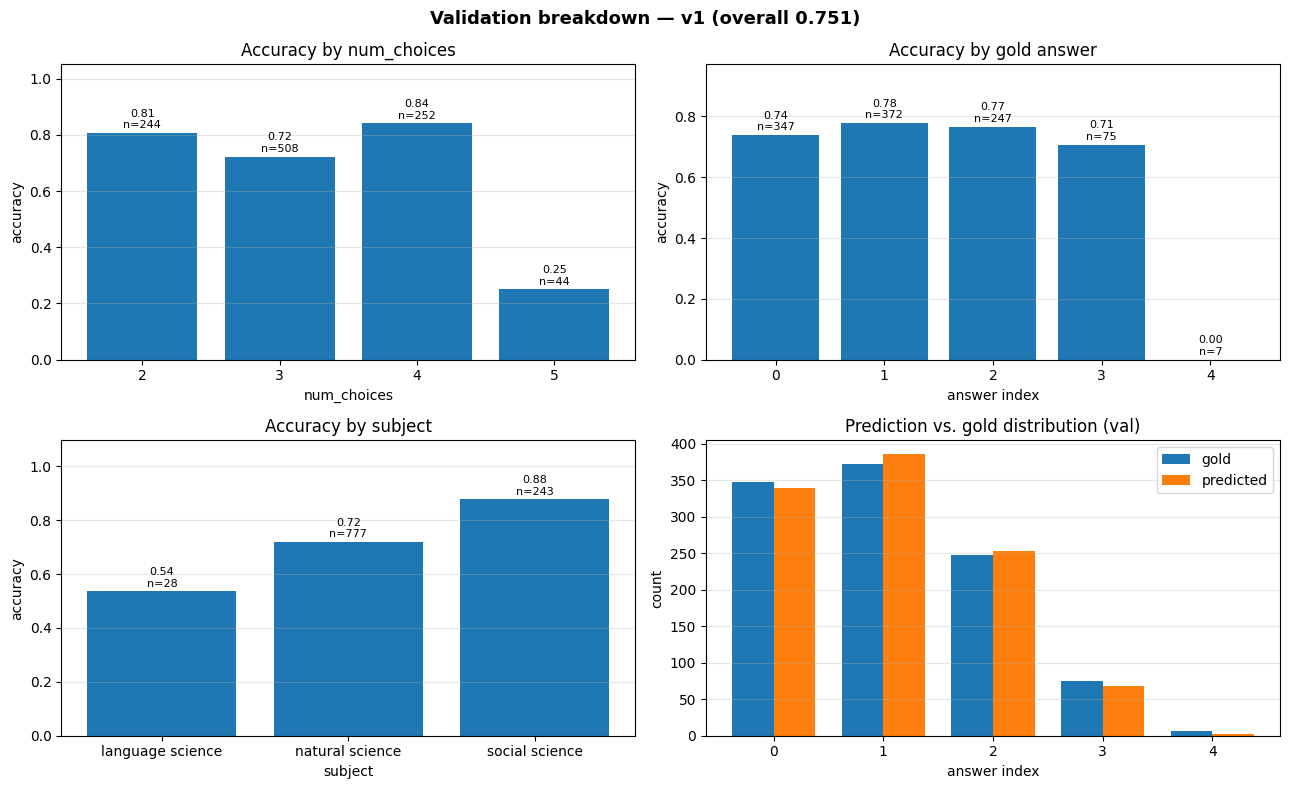

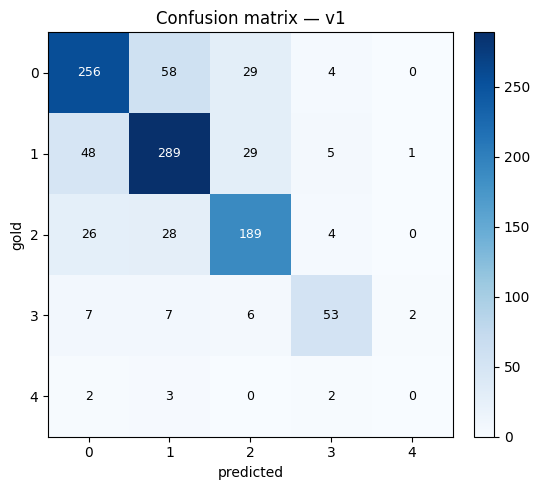

saved -> analysis_plots\v1

v2


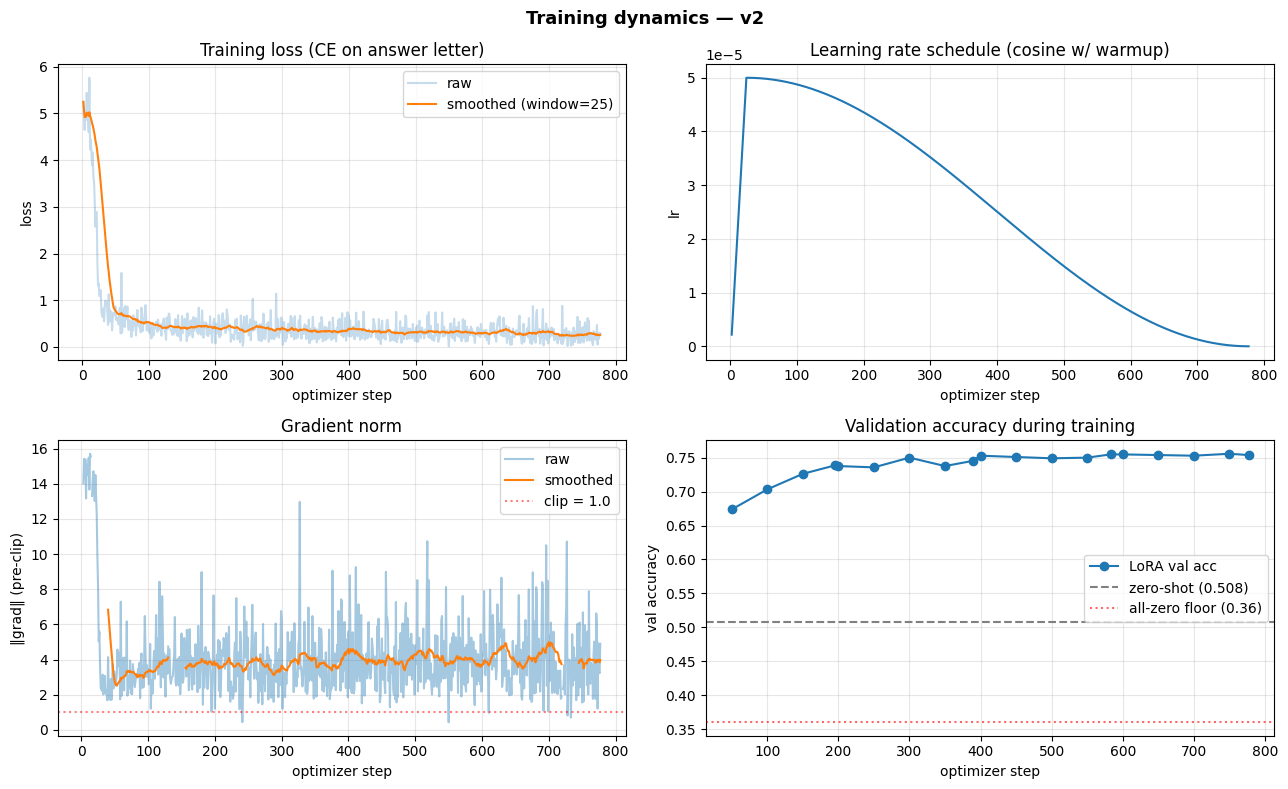

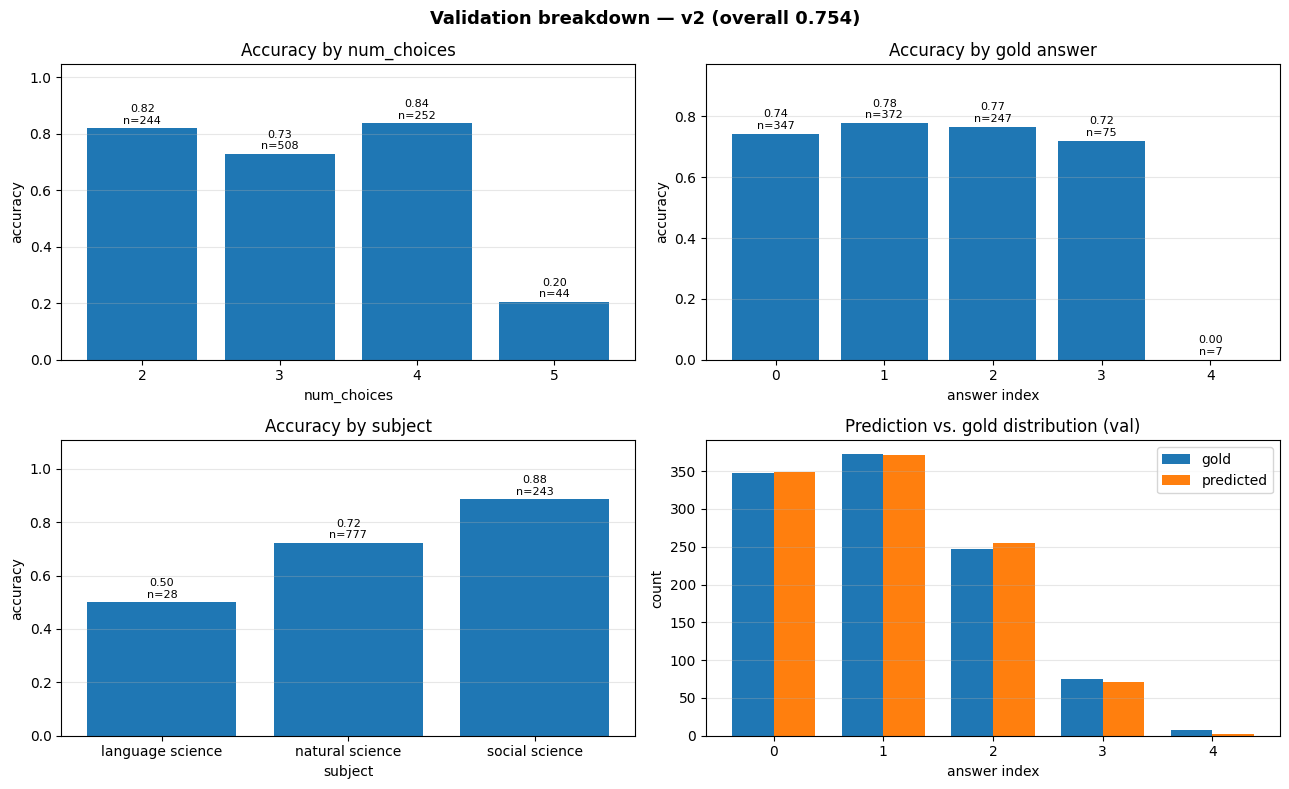

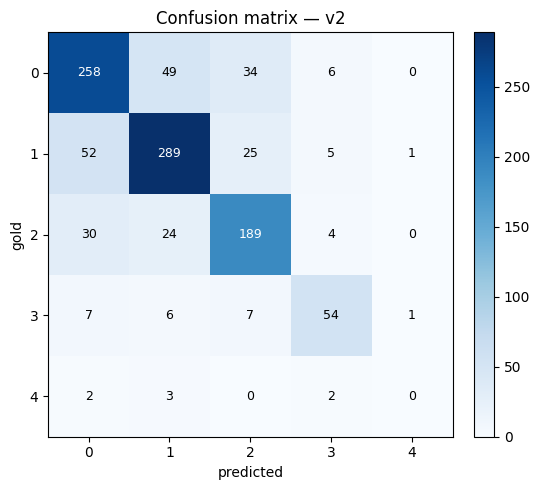

saved -> analysis_plots\v2

v3


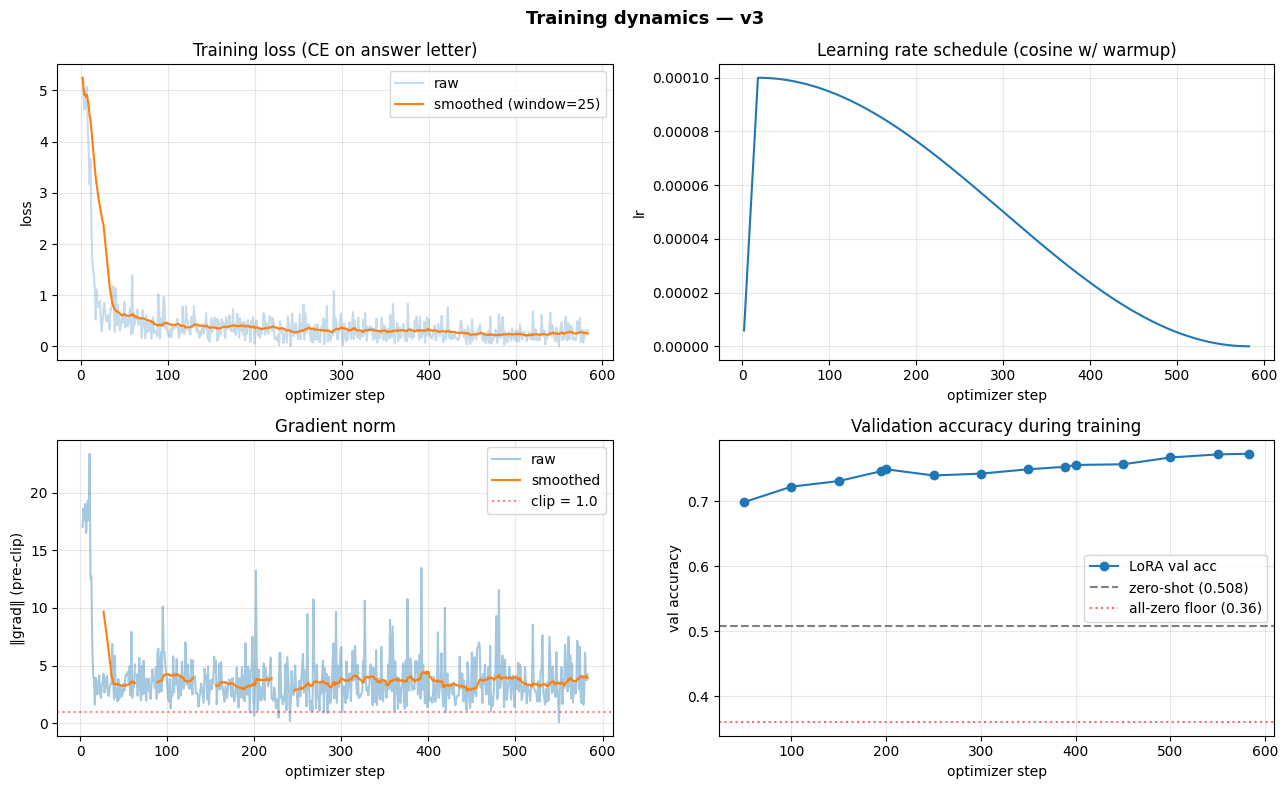

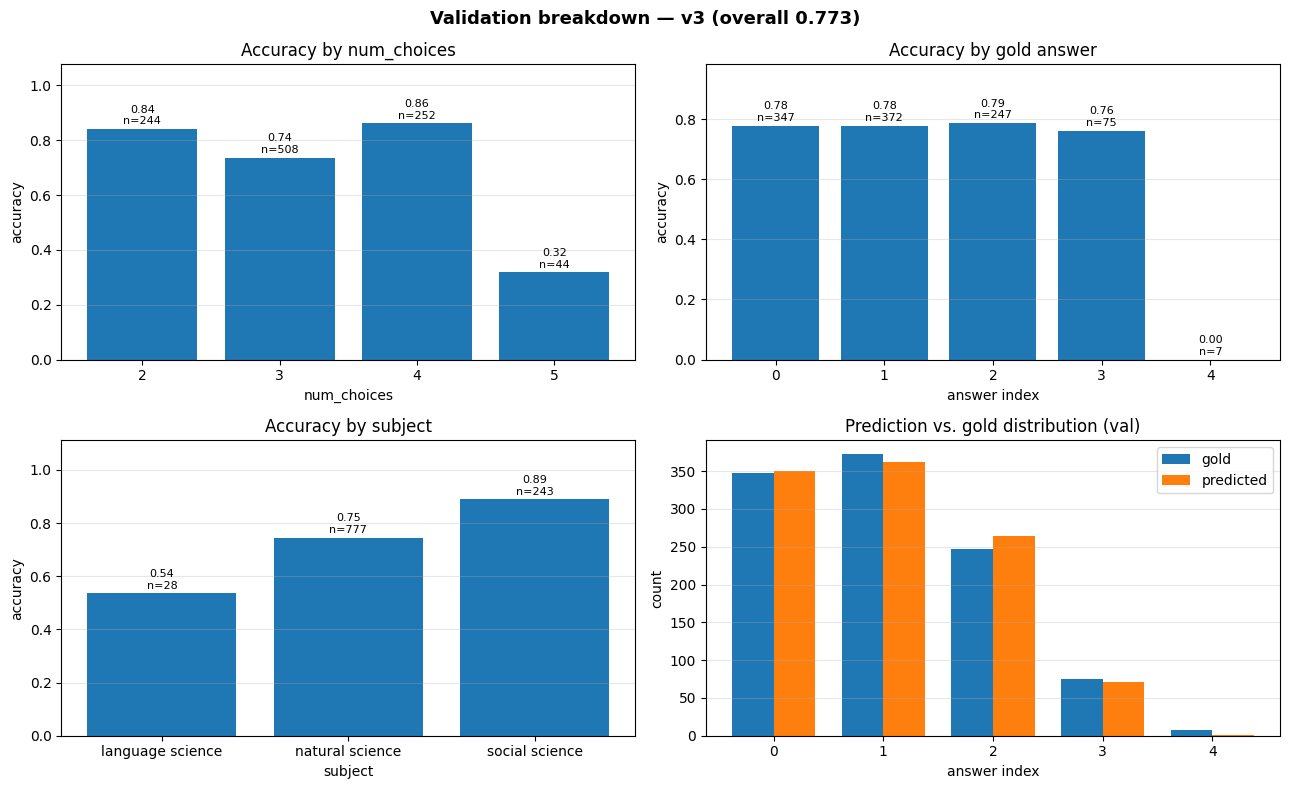

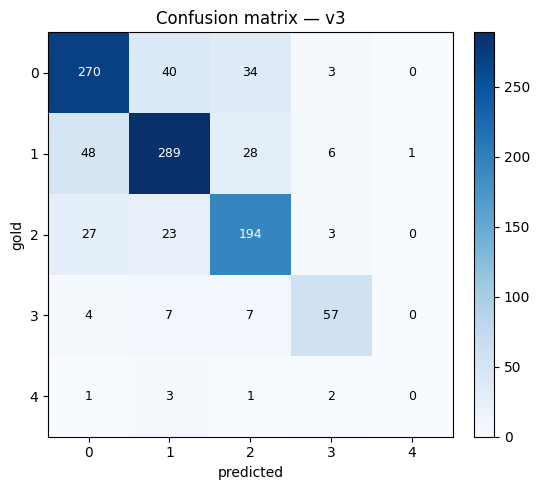

saved -> analysis_plots\v3

v4


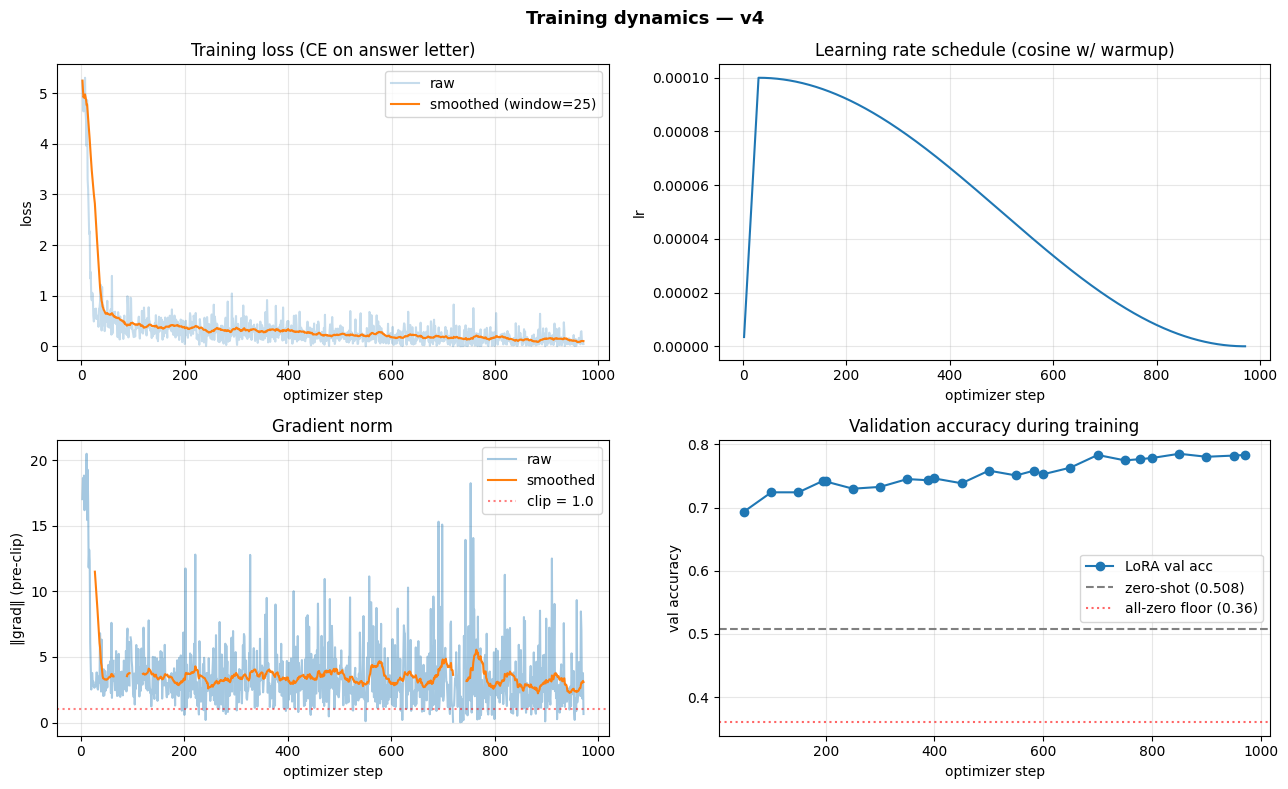

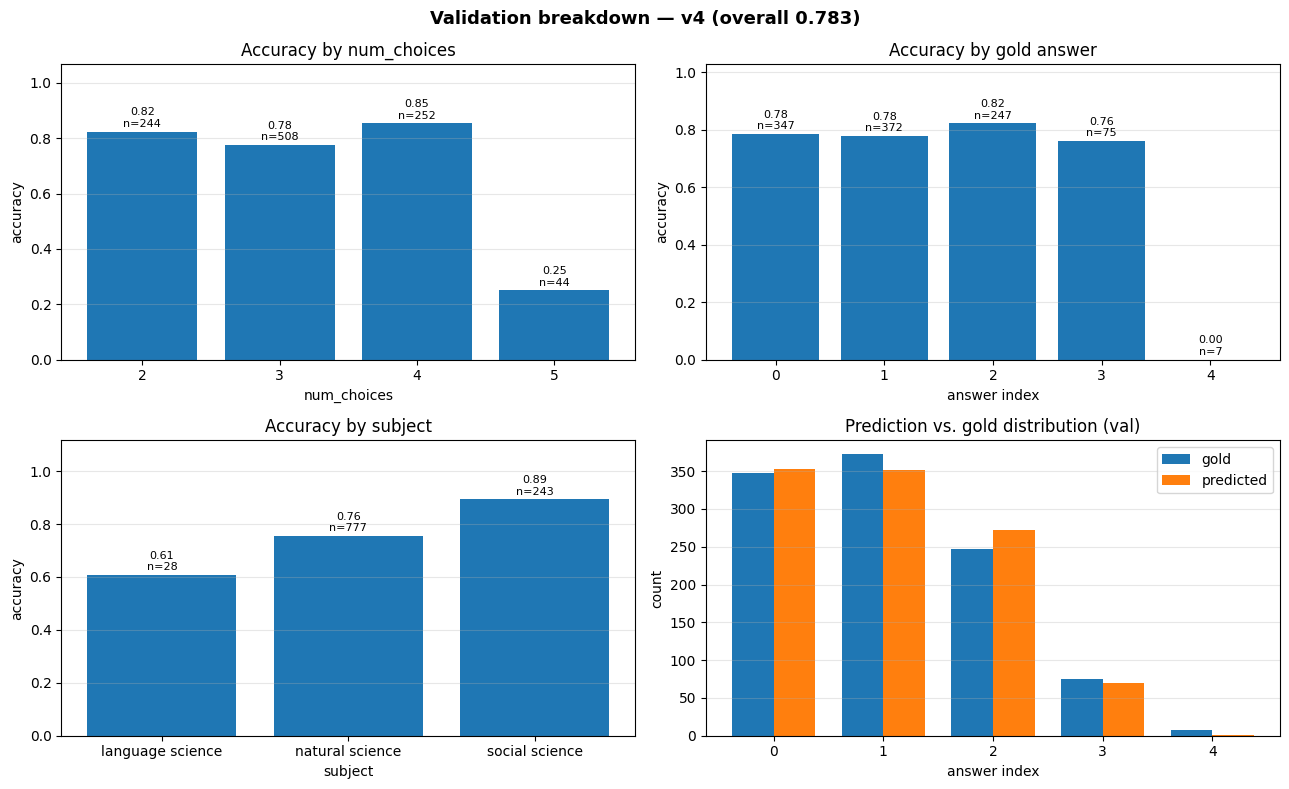

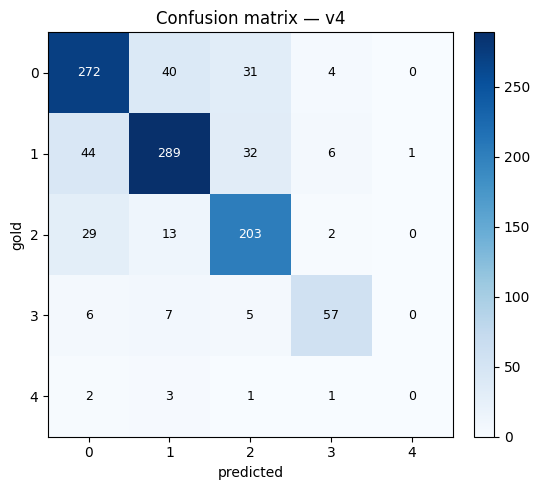

saved -> analysis_plots\v4

v5


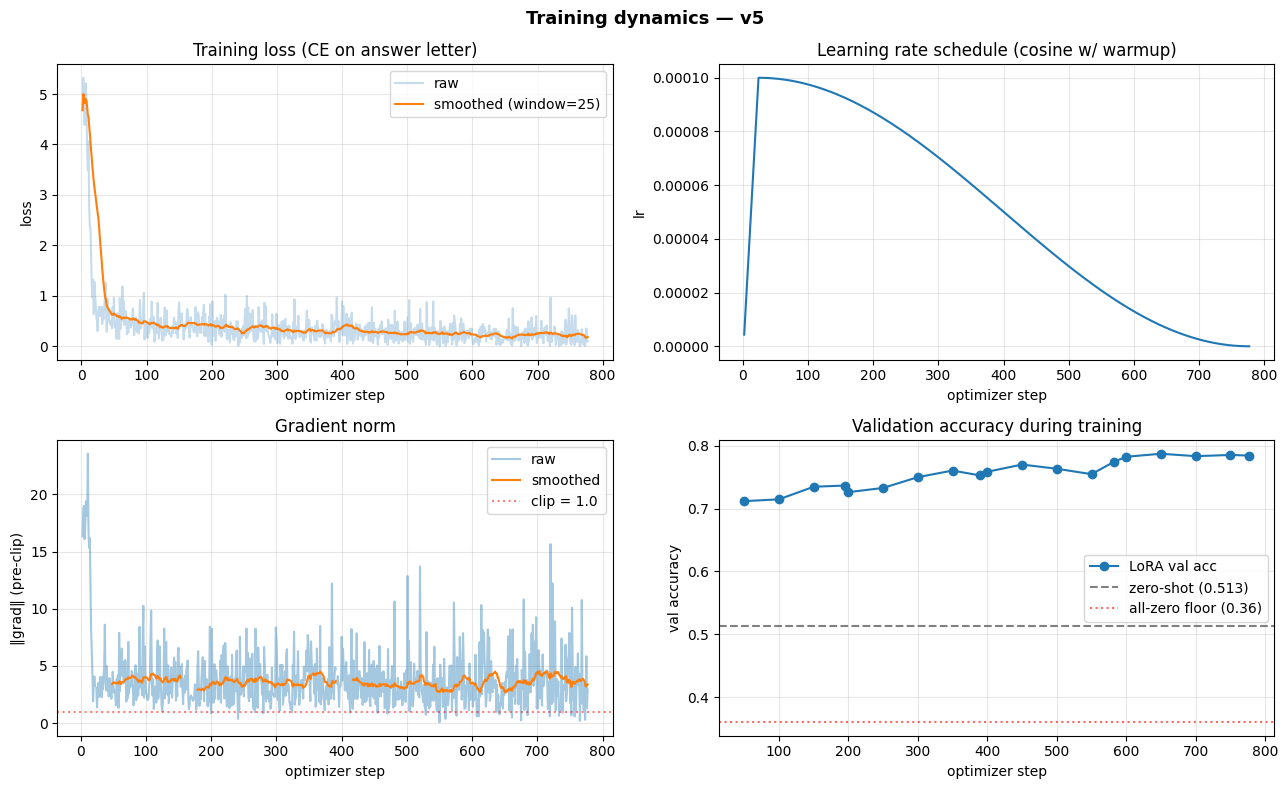

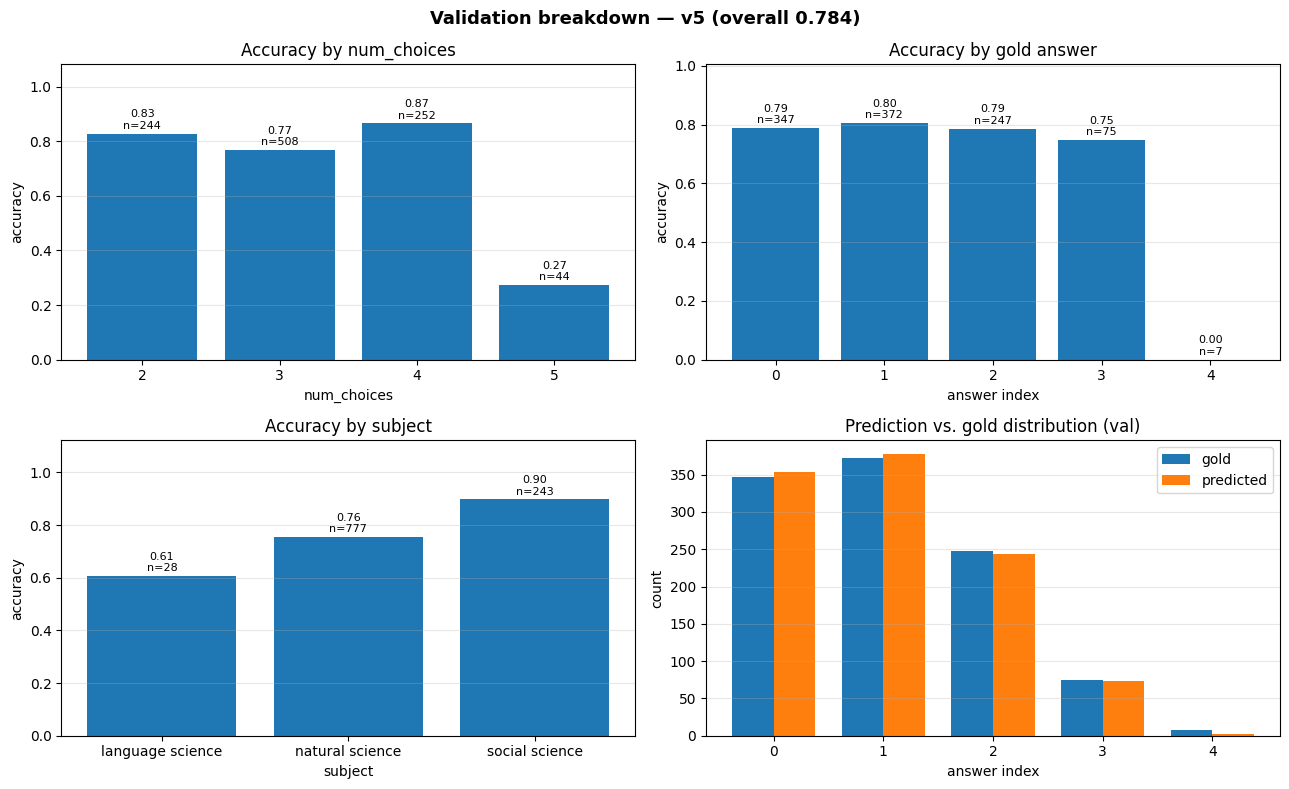

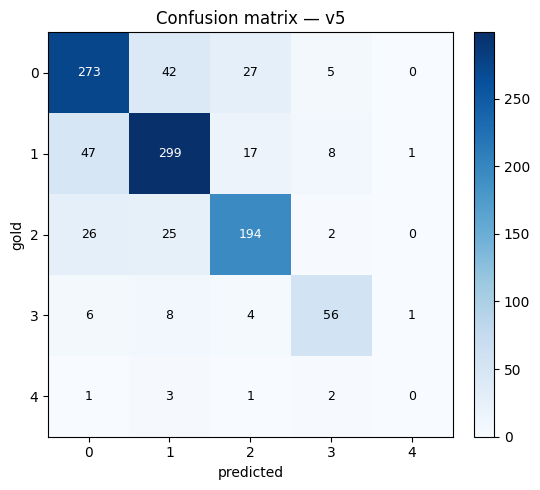

saved -> analysis_plots\v5

v6


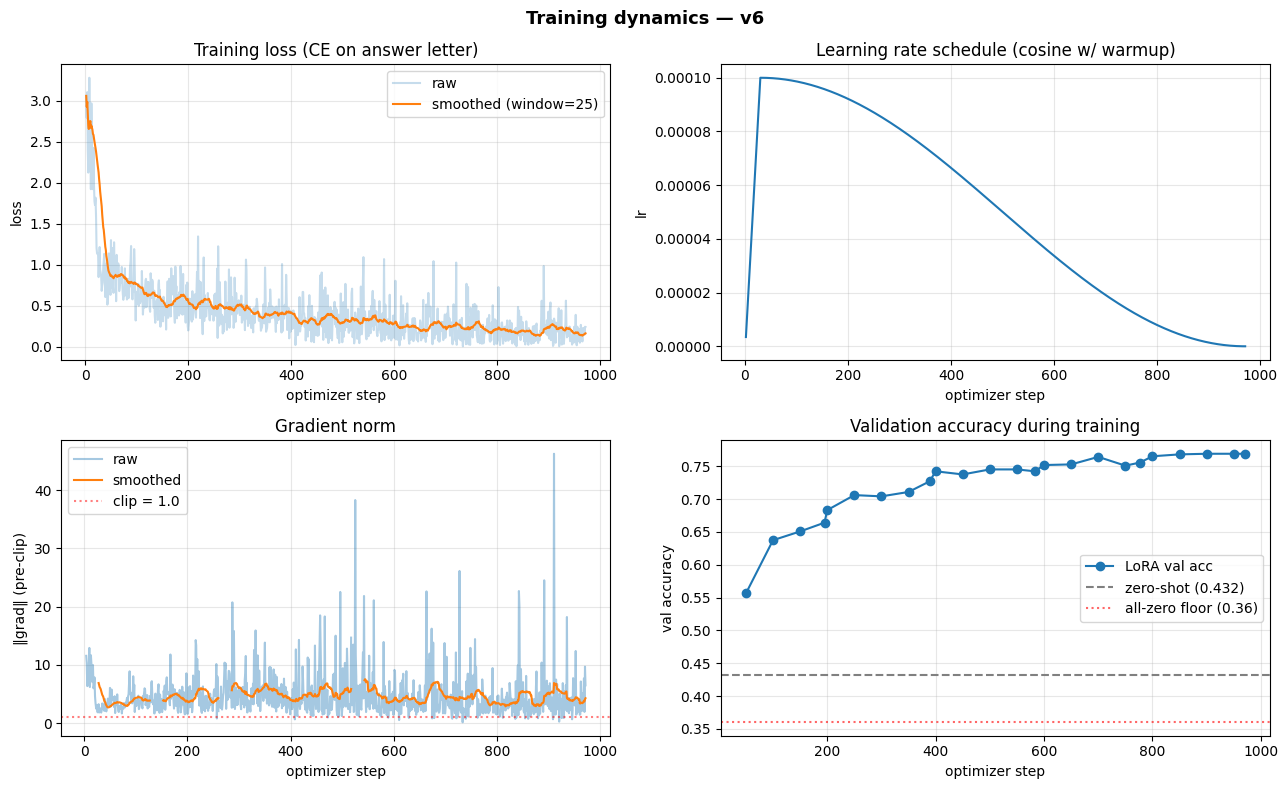

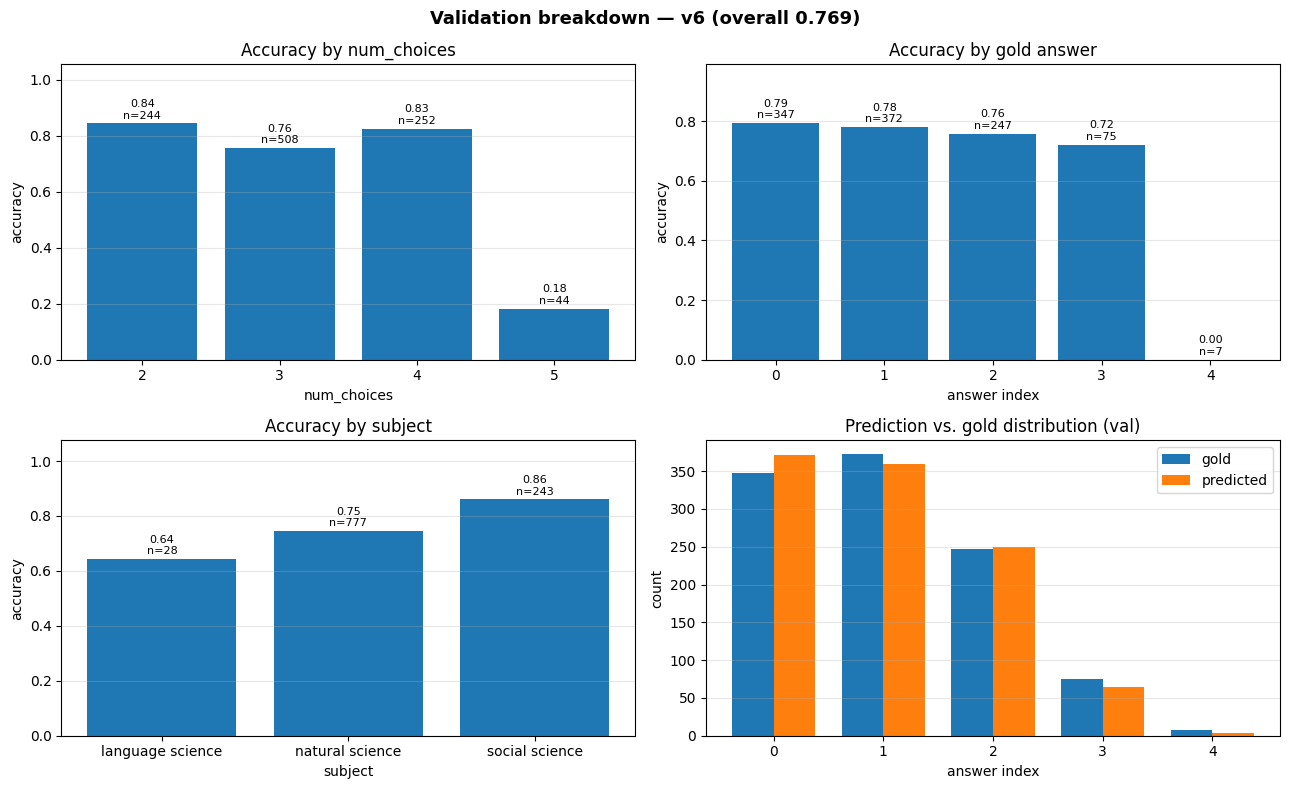

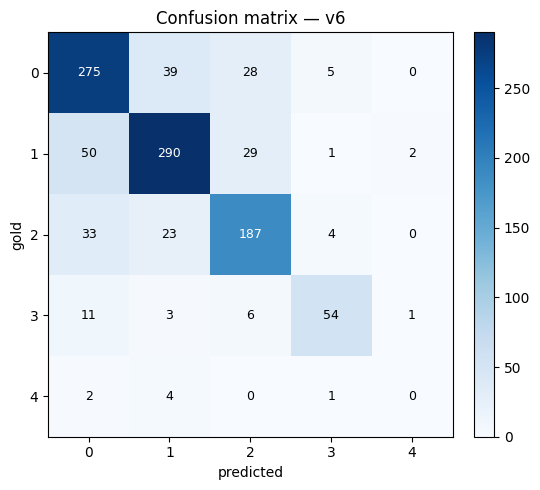

saved -> analysis_plots\v6

v7


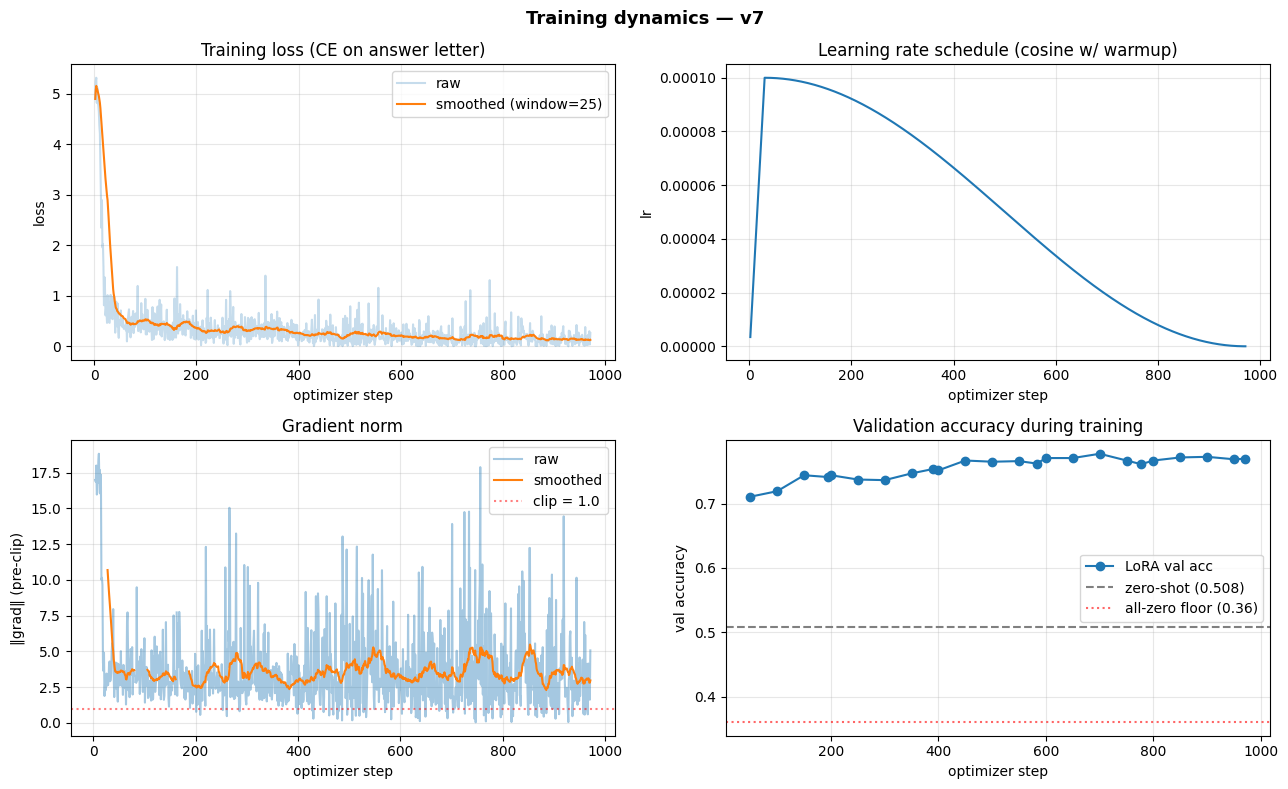

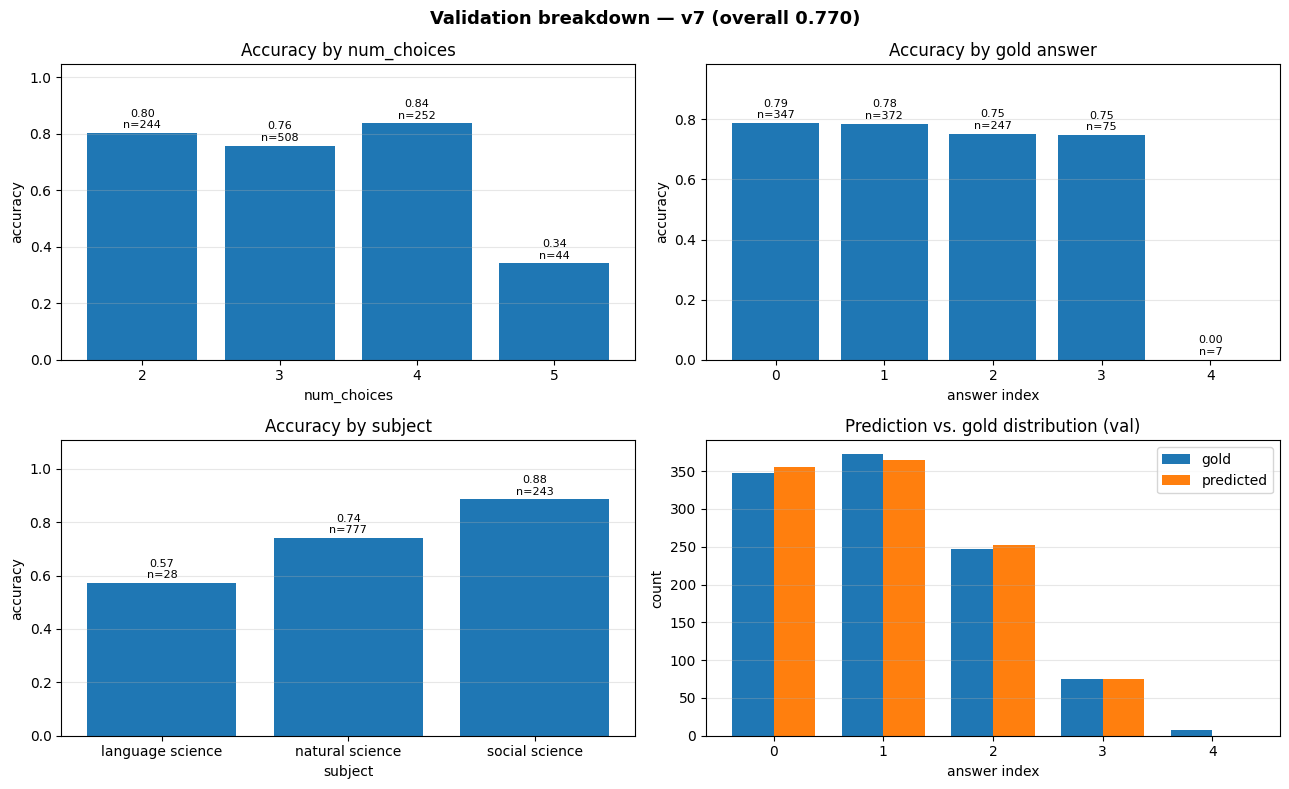

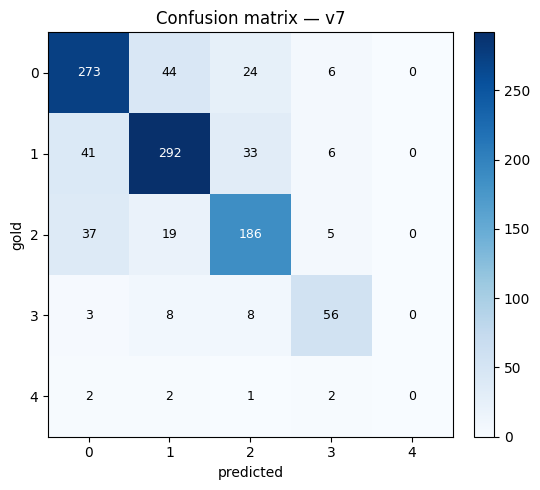

saved -> analysis_plots\v7

v8


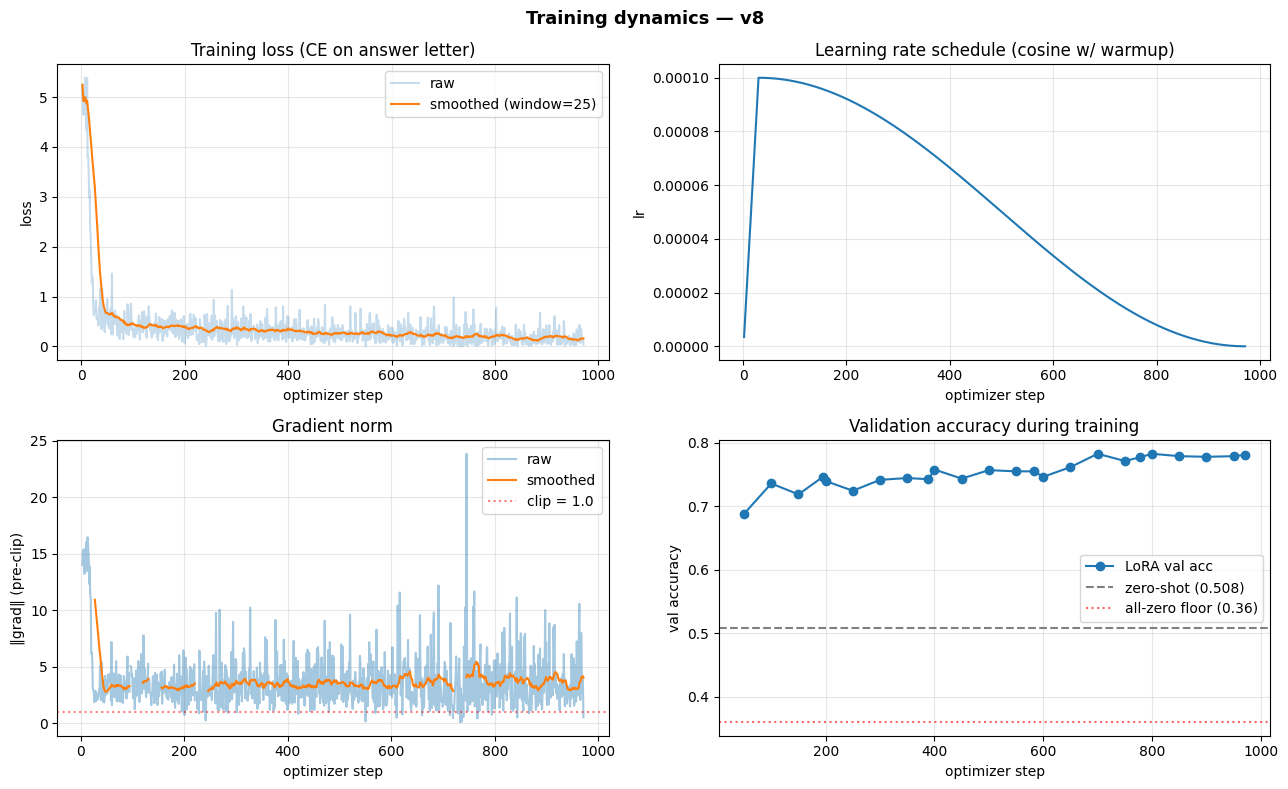

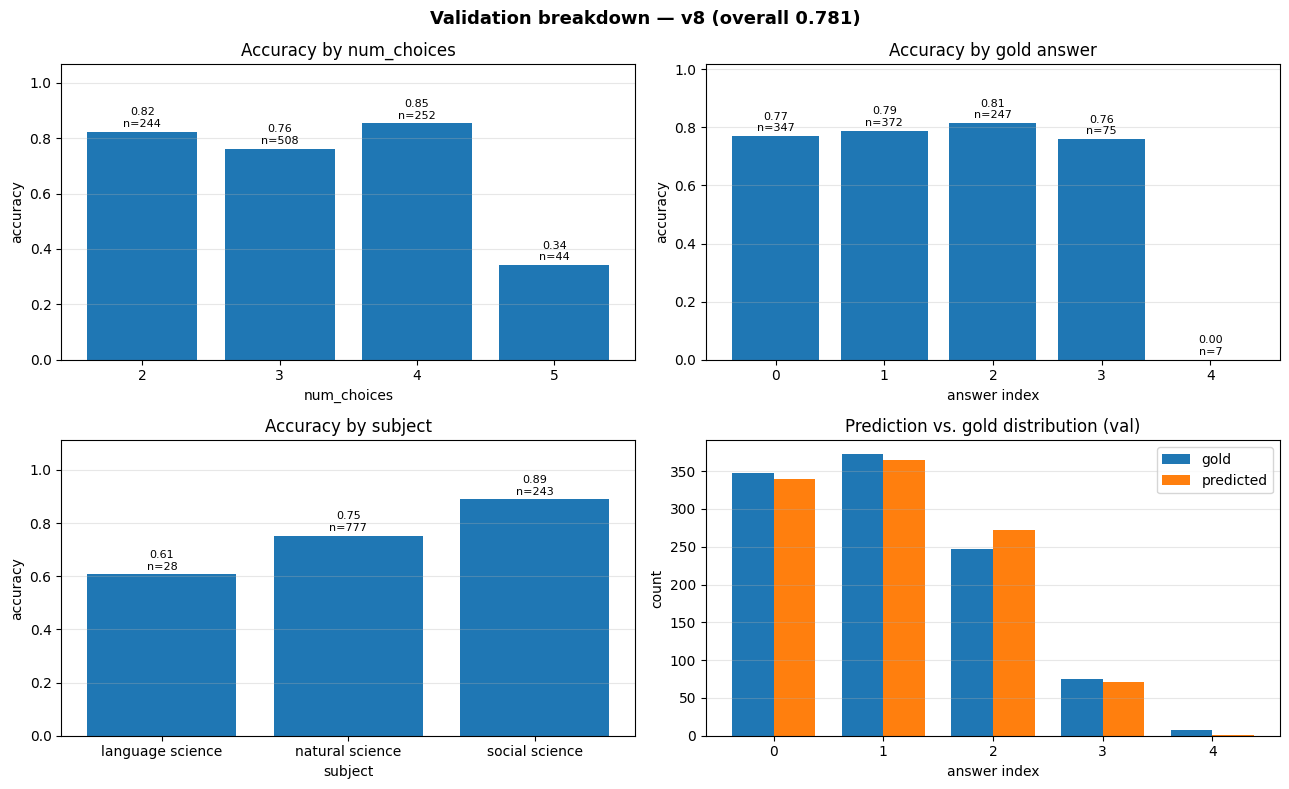

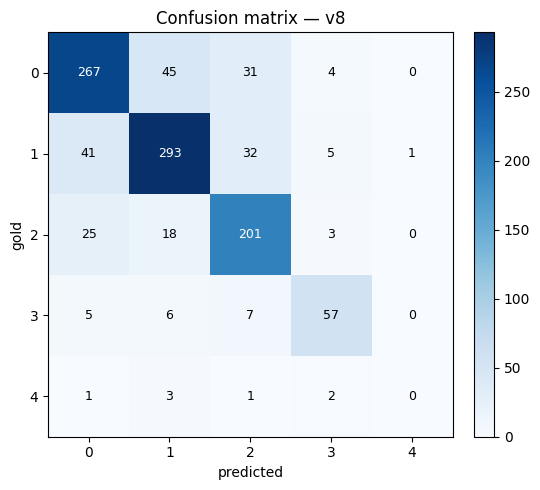

saved -> analysis_plots\v8

v9


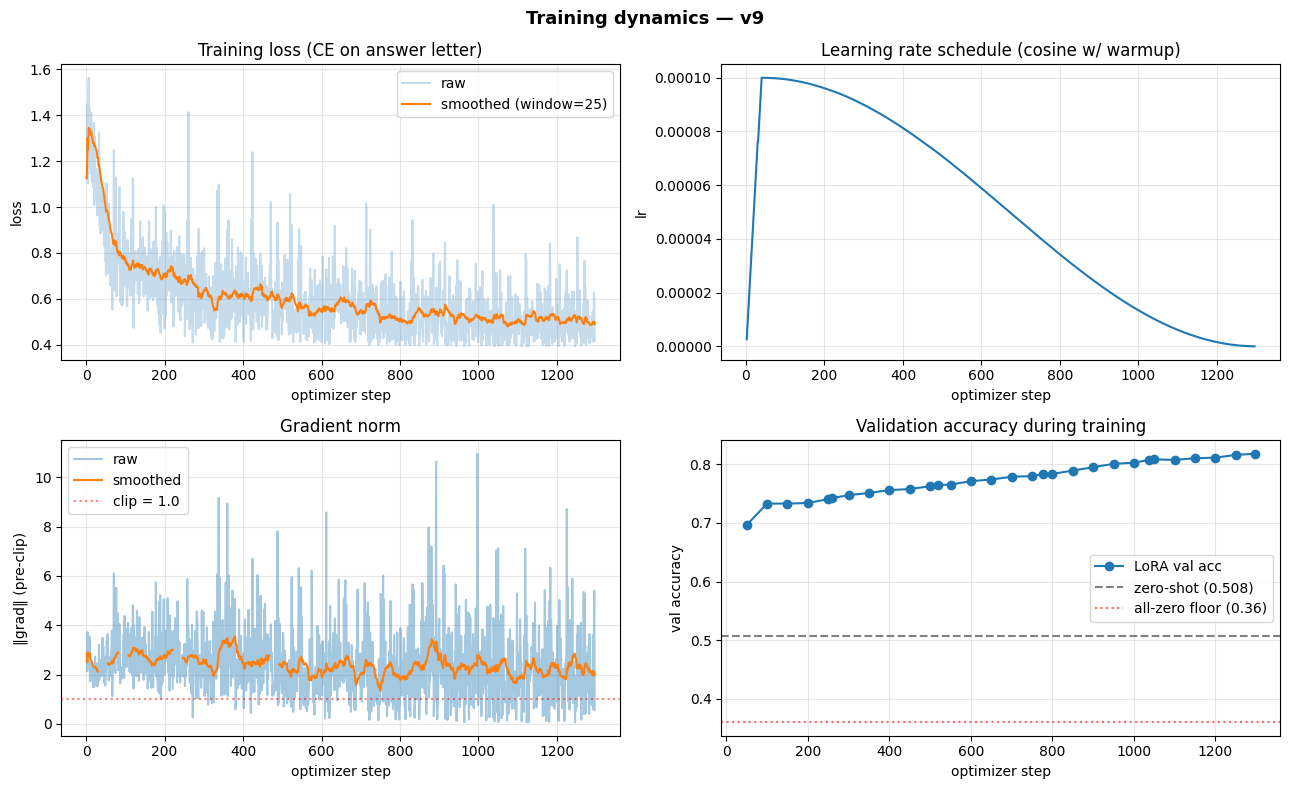

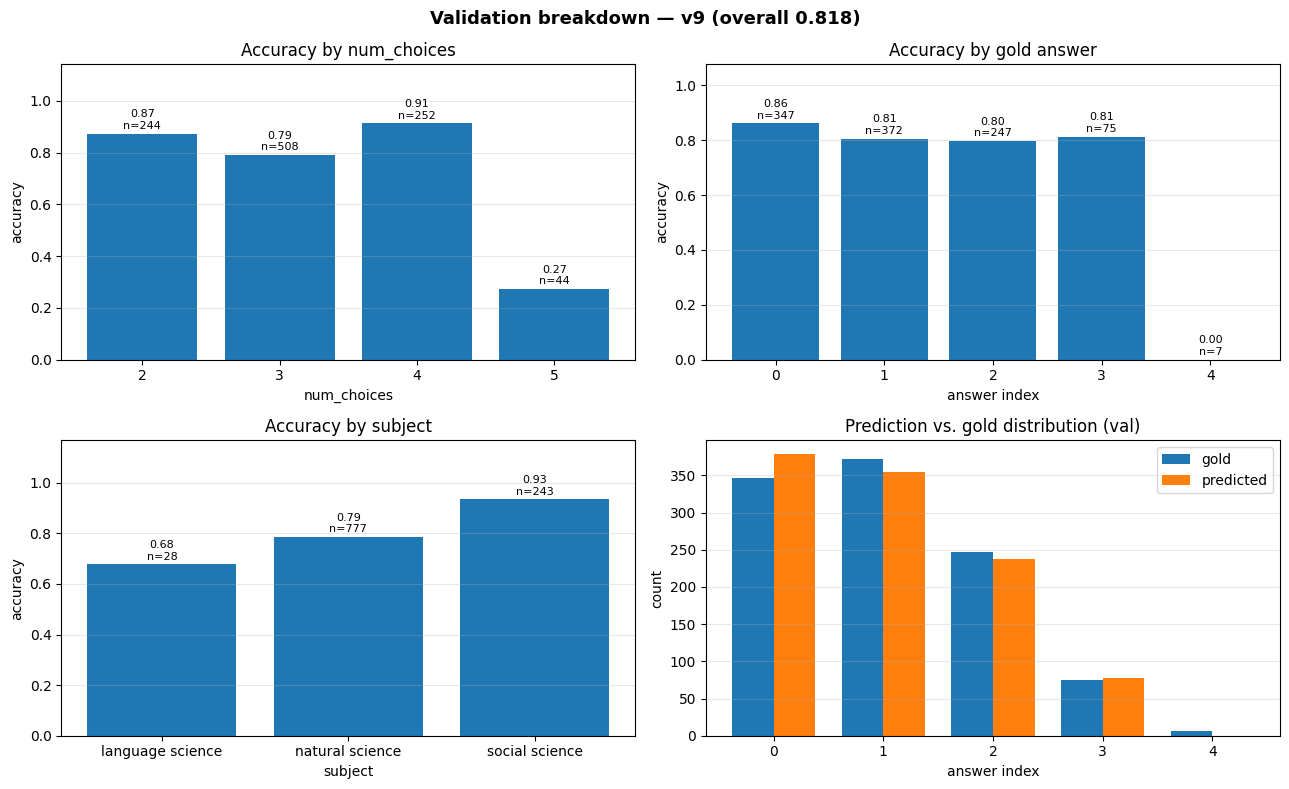

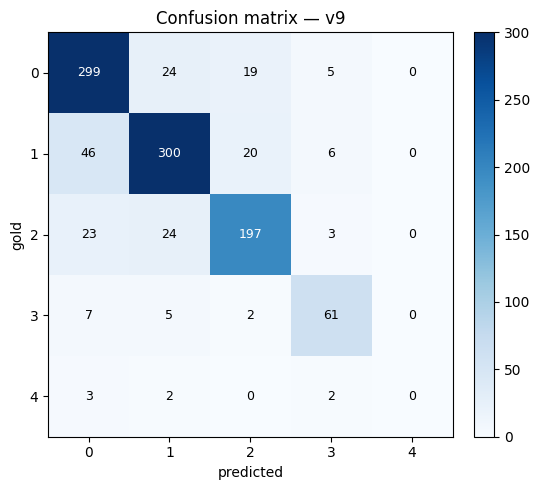

saved -> analysis_plots\v9

v10


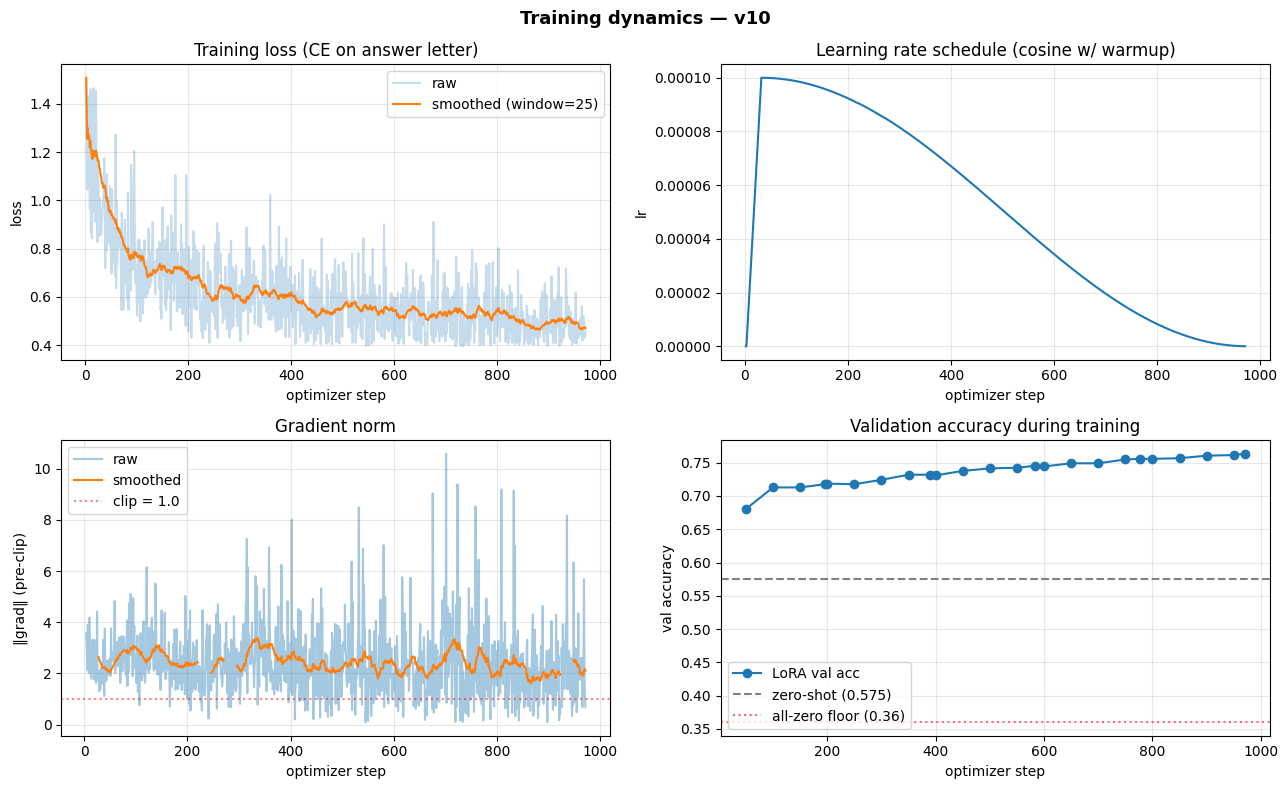

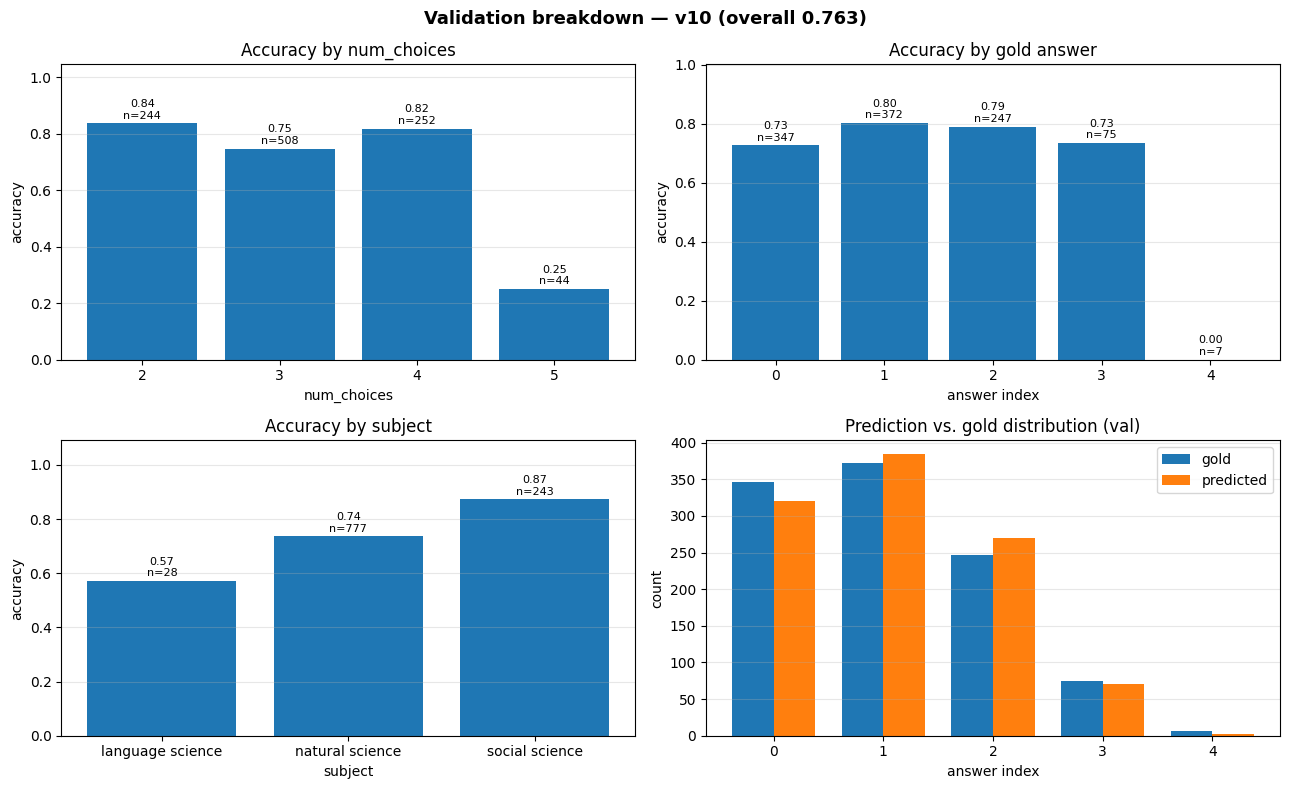

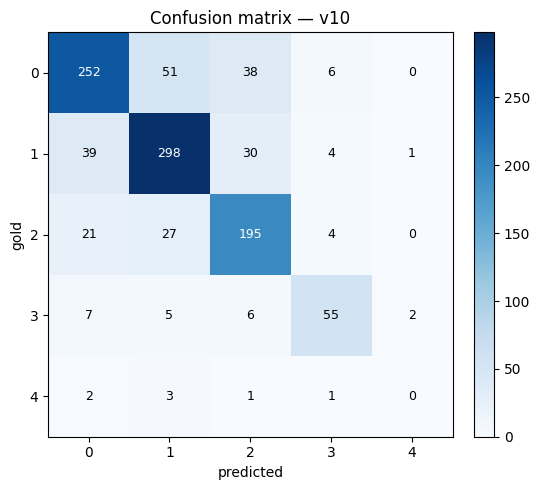

saved -> analysis_plots\v10

v11


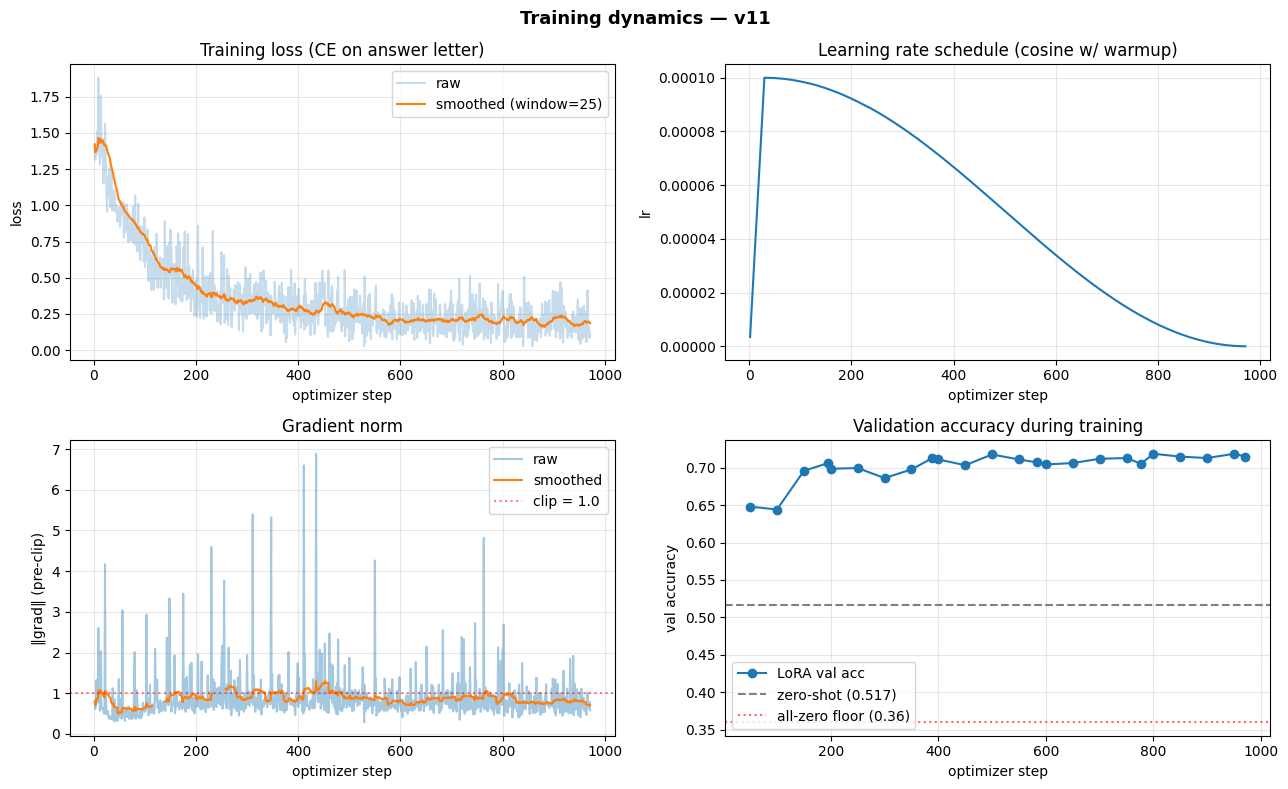

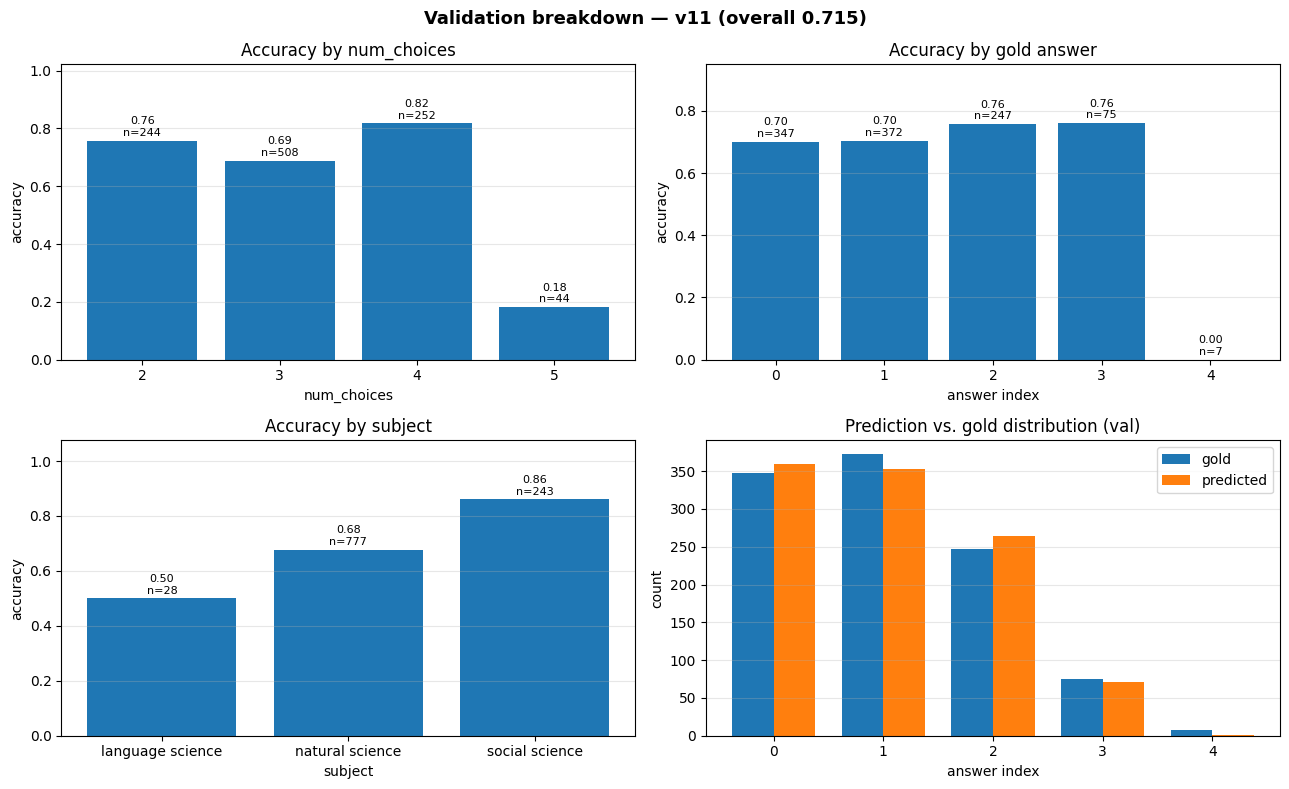

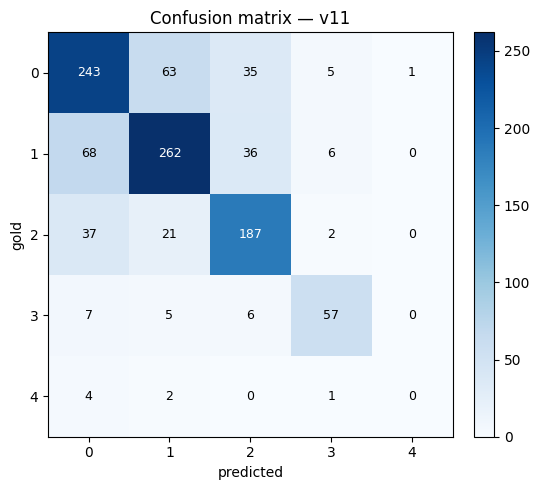

saved -> analysis_plots\v11

v12


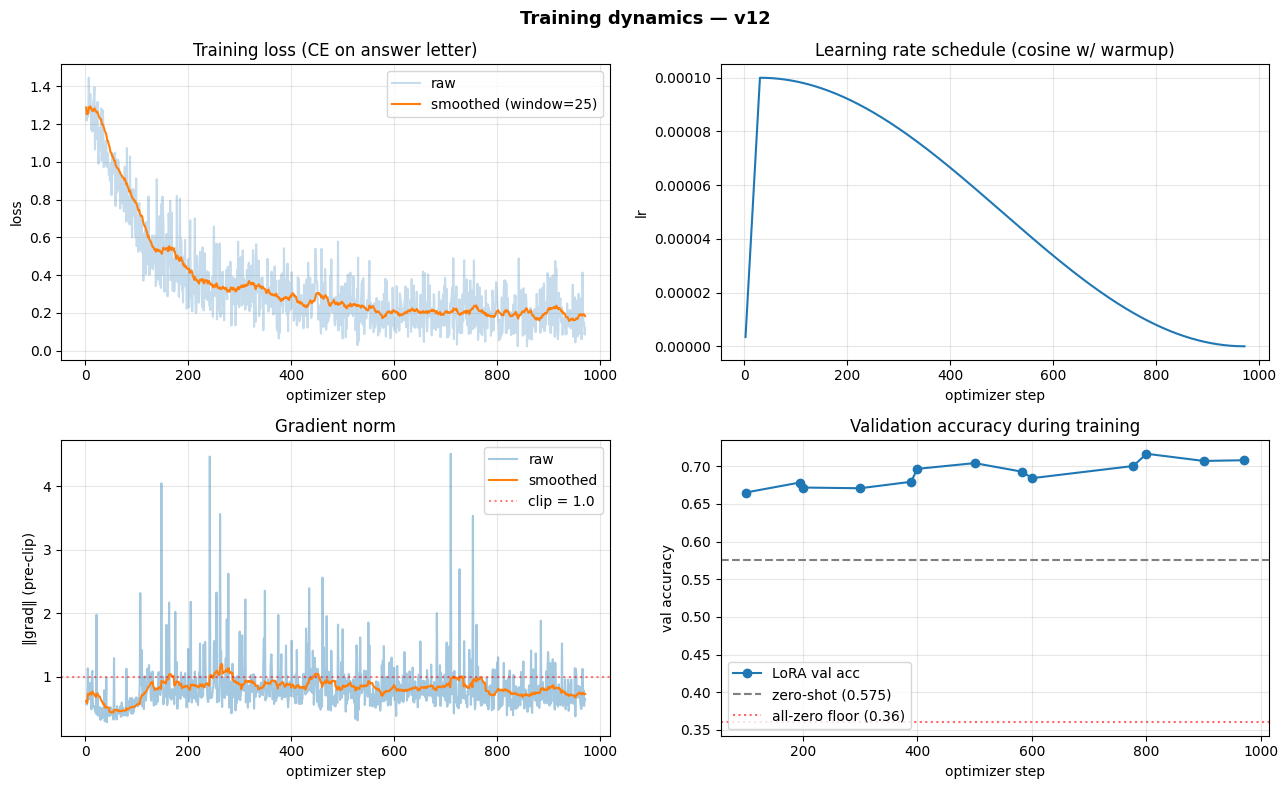

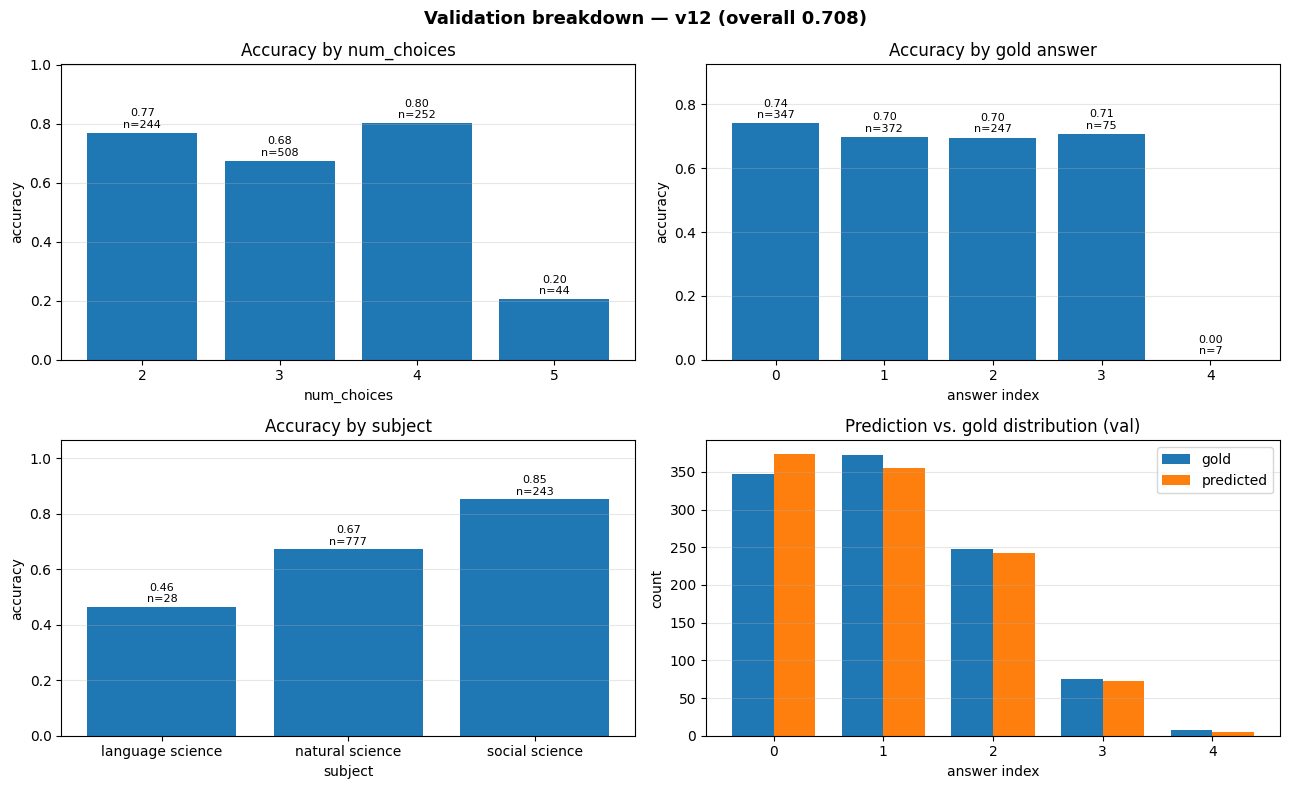

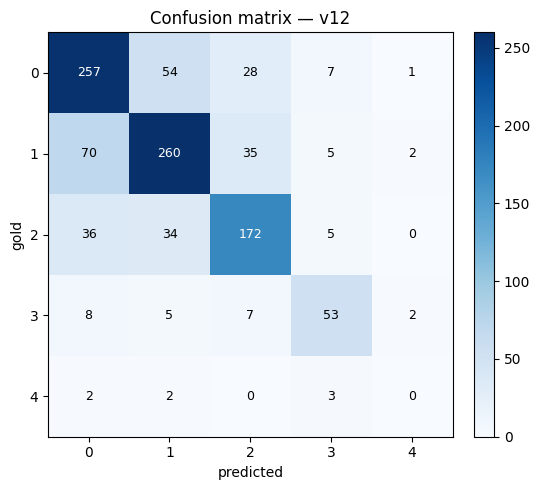

saved -> analysis_plots\v12

v13


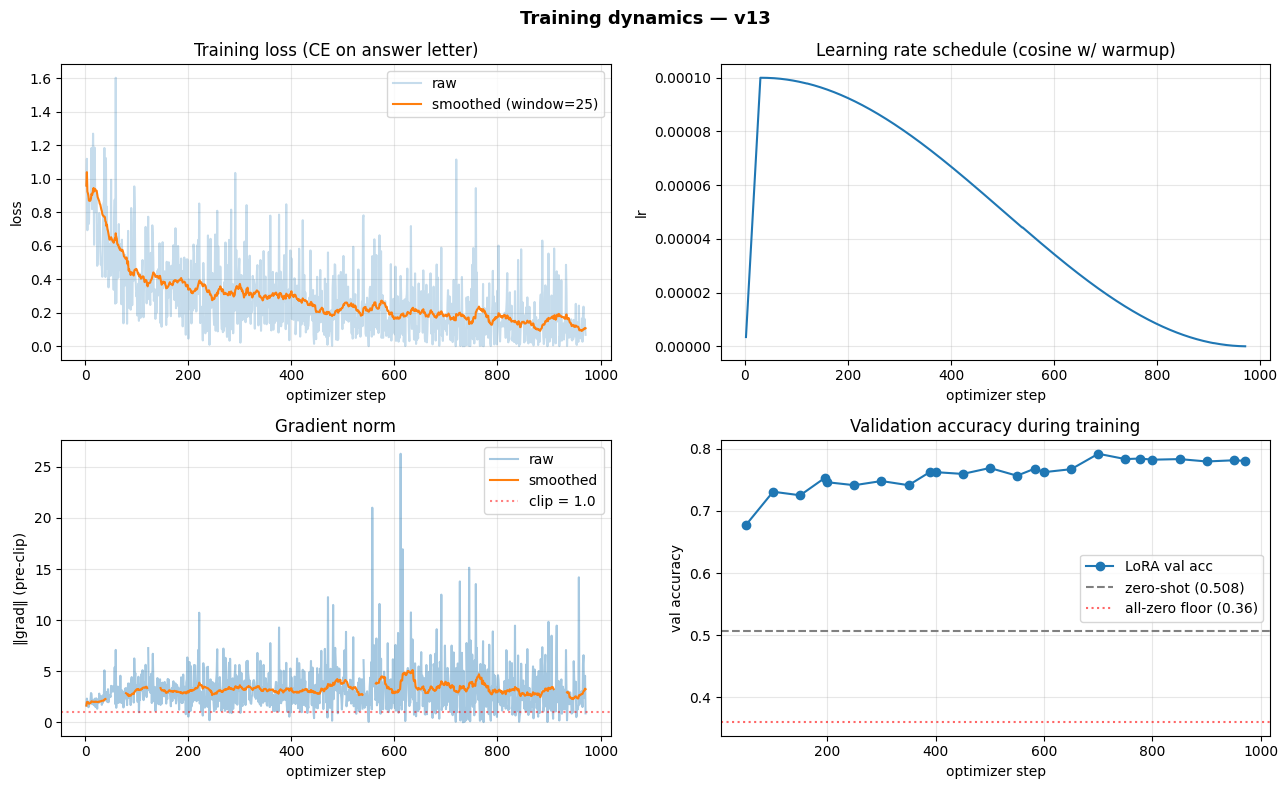

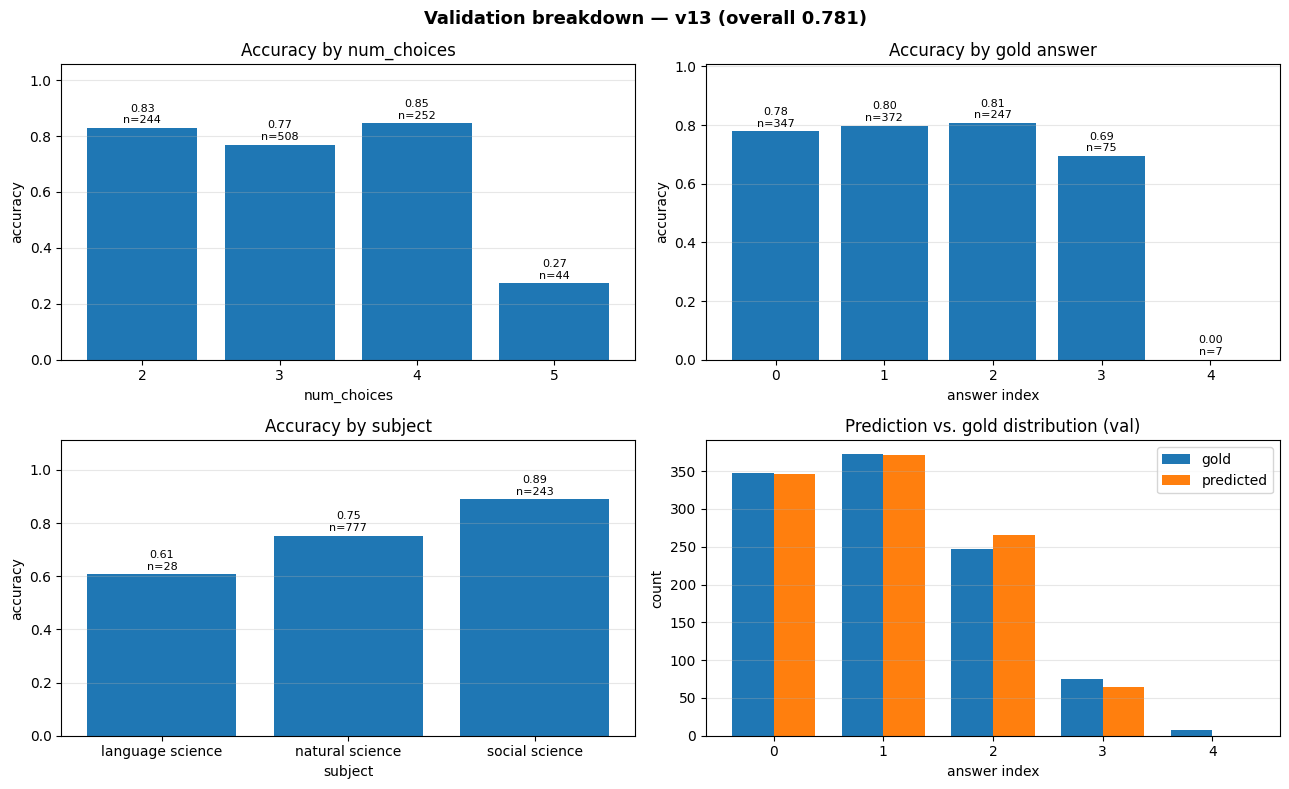

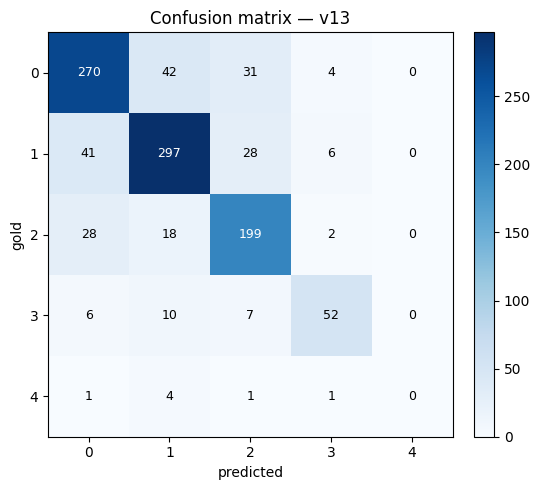

saved -> analysis_plots\v13


In [16]:
for m in loaded:
    v = m["_version"]
    vout = OUT_DIR / v
    vout.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 70 + f"\n{v}\n" + "=" * 70)
    plot_training_dynamics(m, vout / "training_dynamics.png")
    plot_val_breakdown(m,    vout / "val_breakdown.png")
    plot_confusion(m,        vout / "confusion_matrix.png")
    print(f"saved -> {vout}")

## 8. Cross-version comparison

Skipped automatically if only one version is loaded — but the bar chart and summary table still render with one bar/row.

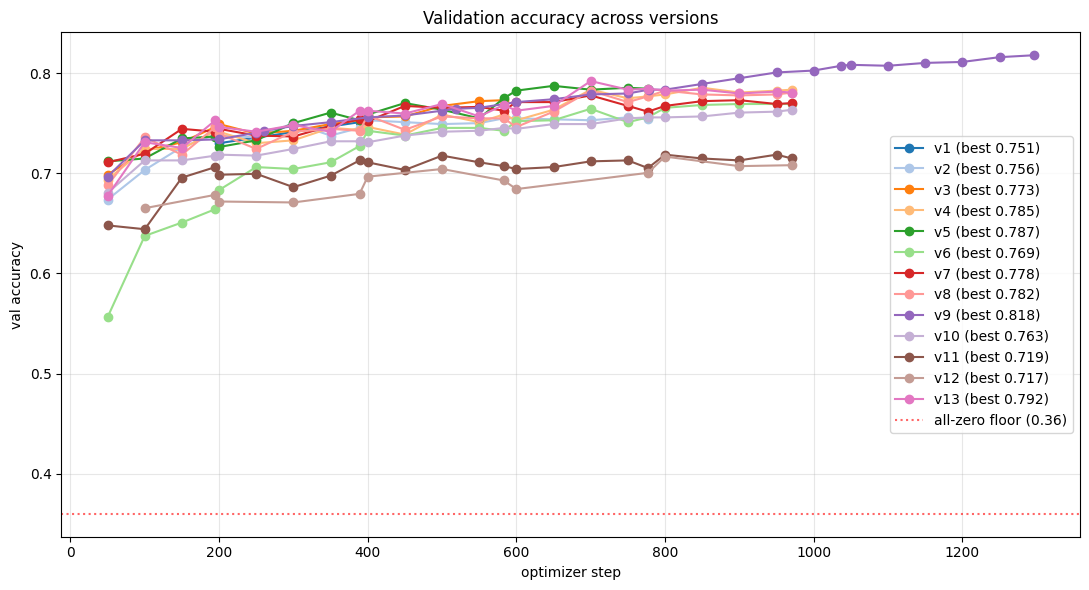

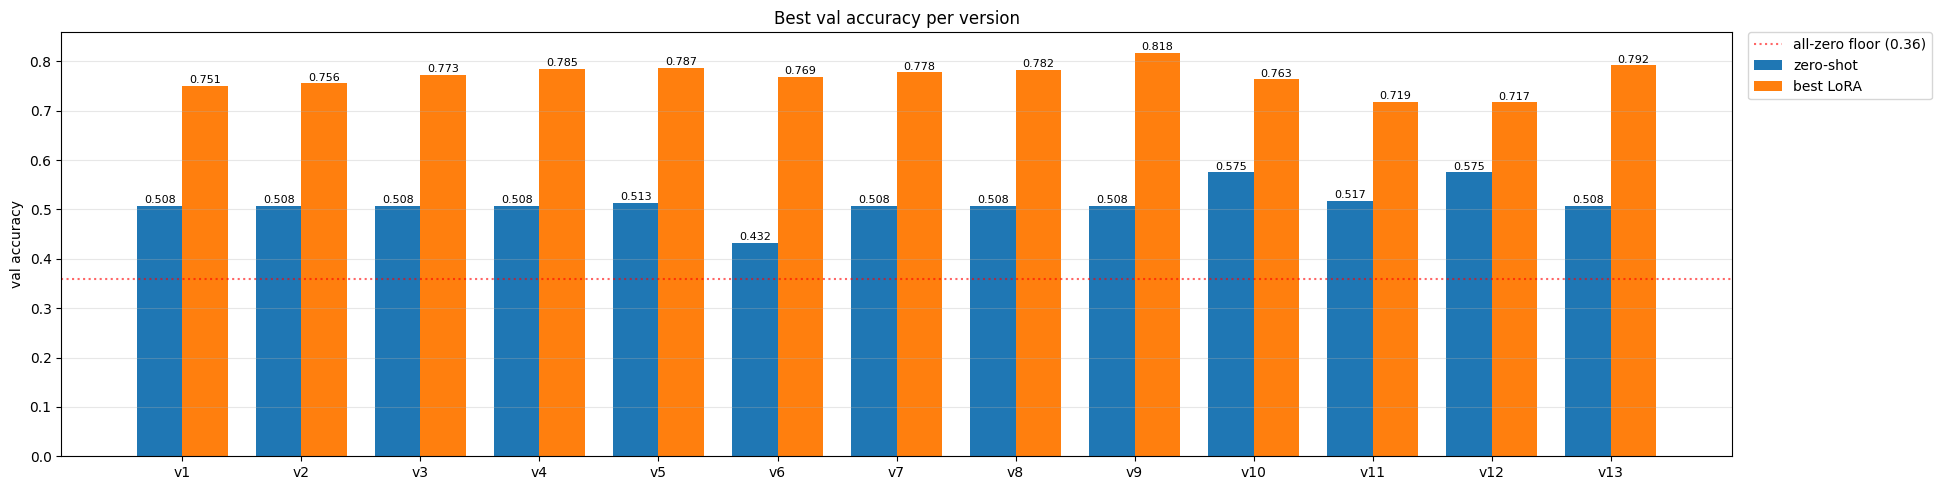


[comparison] saved -> analysis_plots\comparison


In [17]:
cmp_out = OUT_DIR / "comparison"
cmp_out.mkdir(parents=True, exist_ok=True)

if loaded:
    plot_val_curves(loaded,    cmp_out / "val_accuracy_curves.png")
    plot_best_val_bars(loaded, cmp_out / "best_val_accuracy_bars.png")
    summary_df = build_summary_table(loaded, cmp_out / "summary_table.csv")
    print(f"\n[comparison] saved -> {cmp_out}")
else:
    summary_df = None
    print("No versions loaded; nothing to compare.")

## 9. Summary table

All the headline numbers and hyperparameters side-by-side. Same data is on disk at `comparison/summary_table.csv`.

In [18]:
if summary_df is not None:
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    summary_df